In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron

In [2]:
df = pd.read_excel('tr_data.xlsx', index_col=0, parse_dates=True)
print(df.head())

              IGE    YET  GSYH      KRB     FN  ENP
YIL                                                
1990-01-01  0.598  12.23  9.26  151.614  20.66    0
1991-01-01  0.602  11.76  0.72  158.126  24.24    0
1992-01-01  0.608  13.09  5.03  164.064  24.89    0
1993-01-01  0.615  15.38  7.65  171.138  22.40    0
1994-01-01  0.616  14.31 -4.66  167.565  28.92    0


In [3]:
import pandas as pd
df = pd.read_excel("tr_data.xlsx", index_col=0, parse_dates=True)
df.describe()

,IGE,YET,GSYH,KRB,FN,ENP
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,0.717500,12.996875,5.103125,284.305969,39.807187,0.531250
std,0.083538,2.603908,4.177901,93.551922,11.493960,0.507007
min,0.598000,8.230000,-4.820000,151.614000,20.660000,0.000000
25%,0.645500,11.465000,2.857500,211.062750,31.462500,0.000000
50%,0.706000,12.925000,5.920000,273.619000,38.085000,1.000000
75%,0.804500,14.610000,7.705000,358.087250,47.542500,1.000000
max,0.842000,19.000000,11.430000,452.702000,68.570000,1.000000


In [7]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron

df = pd.read_excel('tr_data.xlsx')
df.set_index("YIL", inplace=True)


def unit_root_tests_safe(df):
    results = {}
    for col in df.columns:
        series = df[col].dropna()
        
        if np.var(series) < 1e-8:
            print(f"UYARI: '{col}' değişkeni sabit veya varyansı çok küçük. Test edilmedi.")
            results[col] = {
                'ADF Stat': np.nan,
                'ADF p-değeri': np.nan,
                'PP Stat': np.nan,
                'PP p-değeri': np.nan
            }
            continue
        
        adf_result = adfuller(series, regression='ct', autolag='AIC')
        adf_stat = adf_result[0]
        adf_pvalue = adf_result[1]
        
        pp_test = PhillipsPerron(series)
        pp_stat = pp_test.stat
        pp_pvalue = pp_test.pvalue
        
        results[col] = {
            'ADF Stat': adf_stat,
            'ADF p-değeri': adf_pvalue,
            'PP Stat': pp_stat,
            'PP p-değeri': pp_pvalue
        }
    
    return pd.DataFrame(results).T

# Seviyede Birim Kök Testleri
print("\nSeviyede ADF ve PP Testleri:")
seviye_test_sonuclari = unit_root_tests_safe(df)
print(seviye_test_sonuclari)

#  Durağan Olmayanlar İçin Birinci Fark Alma
df_diff = df.diff().dropna()

print("\nBirinci Fark Alınmış Veriler:")
print(df_diff.head())

#  Birinci Farkta Testler
print("\nBirinci Farkta ADF ve PP Testleri:")
birinci_fark_test_sonuclari = unit_root_tests_safe(df_diff)
print(birinci_fark_test_sonuclari)

# 6. Özet Karar
print("\n========== ÖZET ==========")
for col in df.columns:
    adf_p_seviye = seviye_test_sonuclari.loc[col, 'ADF p-değeri']
    pp_p_seviye = seviye_test_sonuclari.loc[col, 'PP p-değeri']
    
    adf_p_fark = birinci_fark_test_sonuclari.loc[col, 'ADF p-değeri']
    pp_p_fark = birinci_fark_test_sonuclari.loc[col, 'PP p-değeri']
    
    if (adf_p_seviye < 0.05) or (pp_p_seviye < 0.05):
        durum = 'Seviyede durağan (I(0))'
    elif (adf_p_fark < 0.05) or (pp_p_fark < 0.05):
        durum = 'Birinci farkta durağan (I(1))'
    else:
        durum = 'Daha ileri fark alınmalı'
    
    print(f"{col}: {durum}")



Seviyede ADF ve PP Testleri:
      ADF Stat  ADF p-değeri   PP Stat   PP p-değeri
IGE  -3.005358      0.130589 -0.060619  9.532224e-01
YET   0.452211      0.996753 -2.185205  2.116591e-01
GSYH -5.284452      0.000061 -6.065975  1.181576e-07
KRB  -2.529588      0.313331  1.560129  9.977329e-01
FN   -2.561513      0.297920  0.765257  9.910541e-01
ENP  -1.924798      0.641724 -0.944579  7.729377e-01

Birinci Fark Alınmış Veriler:
        IGE   YET   GSYH     KRB    FN  ENP
YIL                                        
1991  0.004 -0.47  -8.54   6.512  3.58  0.0
1992  0.006  1.33   4.31   5.938  0.65  0.0
1993  0.007  2.29   2.62   7.074 -2.49  0.0
1994  0.001 -1.07 -12.31  -3.573  6.52  0.0
1995  0.007  0.62  12.53  13.790  0.66  0.0

Birinci Farkta ADF ve PP Testleri:
      ADF Stat  ADF p-değeri    PP Stat   PP p-değeri
IGE  -2.849654      0.179305  -4.425585  2.673679e-04
YET  -4.303893      0.003103  -6.364251  2.431847e-08
GSYH -3.253453      0.074267 -15.816343  1.032458e-28
KRB  -4.

In [7]:
pip install arch

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
from arch.unitroot import ZivotAndrews

df = pd.read_excel("tr_data.xlsx")
df.set_index("YIL", inplace=True)

def zivot_andrews_test(dataframe):
    results = {}
    for col in dataframe.columns:
        series = dataframe[col].dropna().astype(float)

        if len(series) < 25 or series.var() < 1e-8:
            results[col] = {
                "ZA Stat": None,
                "p-değeri": None,
                "Kritik Değer (5%)": None
            }
            continue

        try:
            za_test = ZivotAndrews(series, lags=1, trend='c')
            results[col] = {
                "ZA Stat": round(za_test.stat, 6),
                "p-değeri": round(za_test.pvalue, 6),
                "Kritik Değer (1%)": za_test.critical_values['1%'],
                "Kritik Değer (5%)": za_test.critical_values['5%'],
                "Kritik Değer (10%)": za_test.critical_values['10%']
            
}
        
        except Exception as e:
            results[col] = {
                "ZA Stat": None,
                "p-değeri": None,
                "Kritik Değer (5%)": f"Hata: {str(e)}"
            }

    return pd.DataFrame(results).T

za_sonuclari = zivot_andrews_test(df)
print("\nZivot-Andrews Test Sonuçları:")
print(za_sonuclari)



Zivot-Andrews Test Sonuçları:
           ZA Stat  p-değeri  Kritik Değer (1%)  Kritik Değer (5%)  \
IGE  -3.456601e+00  0.707143           -5.27644           -4.81067   
YET  -3.530255e+00  0.660052           -5.27644           -4.81067   
GSYH -4.809891e+00  0.050145           -5.27644           -4.81067   
KRB  -4.851776e+00  0.045386           -5.27644           -4.81067   
FN   -2.537435e+00  0.982321           -5.27644           -4.81067   
ENP  -1.197409e+15  0.000010           -5.27644           -4.81067   

      Kritik Değer (10%)  
IGE             -4.56618  
YET             -4.56618  
GSYH            -4.56618  
KRB             -4.56618  
FN              -4.56618  
ENP             -4.56618  


In [11]:
import statsmodels.api as sm


y = df['IGE']

X = df[['YET', 'GSYH', 'KRB', 'FN', 'ENP']]
X = sm.add_constant(X)

split_date = '2005-01-01'
X_pre2000 = X.loc[:split_date]
y_pre2000 = y.loc[:split_date]
X_post2000 = X.loc[split_date:]
y_post2000 = y.loc[split_date:]

model_pre = sm.OLS(y_pre2000, X_pre2000).fit()
model_post = sm.OLS(y_post2000, X_post2000).fit()
model_full = sm.OLS(y, X).fit()

# Chow testi için F istatistiği
n_full = len(y)
n_pre = len(y_pre2000)
n_post = len(y_post2000)
k = X.shape[1] 

SSR_full = np.sum(model_full.resid ** 2)
SSR_pre = np.sum(model_pre.resid ** 2)
SSR_post = np.sum(model_post.resid ** 2)

# F istatistiği
numerator = (SSR_full - (SSR_pre + SSR_post)) / k
denominator = (SSR_pre + SSR_post) / (n_pre + n_post - 2*k)
F_stat = numerator / denominator

print(f"Chow Testi F-istatistiği: {F_stat:.4f}")

Chow Testi F-istatistiği: 1.8221


In [13]:
import numpy as np
import statsmodels.api as sm
from scipy import stats

df1 = df.loc[1990:2004] 
df2 = df.loc[2005:2021]   


y_full  = df["IGE"]
X_full  = sm.add_constant(df[["YET", "KRB", "GSYH", "FN", "ENP"]])

y1, X1  = df1["IGE"], sm.add_constant(df1[["YET", "KRB", "GSYH", "FN", "ENP"]])
y2, X2  = df2["IGE"], sm.add_constant(df2[["YET", "KRB", "GSYH", "FN", "ENP"]])


res_full = sm.OLS(y_full, X_full).fit()
res1 = sm.OLS(y1, X1).fit()
res2 = sm.OLS(y2, X2).fit()

# RSS
RSS_full = np.sum(res_full.resid ** 2)
RSS1 = np.sum(res1.resid ** 2)
RSS2 = np.sum(res2.resid ** 2)

# Chow F-istatistiği ve p-değeri
k = X_full.shape[1]
n1, n2 = len(df1), len(df2)

numerator = (RSS_full - (RSS1 + RSS2)) / k
denominator = (RSS1 + RSS2) / (n1 + n2 - 2 * k)
F_stat = numerator / denominator
p_value = 1 - stats.f.cdf(F_stat, k, n1 + n2 - 2 * k)

print(f"Chow Testi → F-istatistiği = {F_stat:.3f}, p-değeri = {p_value:.3f}")
if p_value < 0.05:
    print("→ Kırılma sonrası modelde anlamlı farklılık var.")
else:
    print("→ Kırılma etkisi saptanamadı.")

print(f"\nn1 = {n1}, n2 = {n2}, k = {k}")
print(f"RSS_full = {RSS_full:.4f}, RSS1 = {RSS1:.4f}, RSS2 = {RSS2:.4f}")


Chow Testi → F-istatistiği = 1.742, p-değeri = 0.163
→ Kırılma etkisi saptanamadı.

n1 = 15, n2 = 17, k = 6
RSS_full = 0.0060, RSS1 = 0.0009, RSS2 = 0.0031


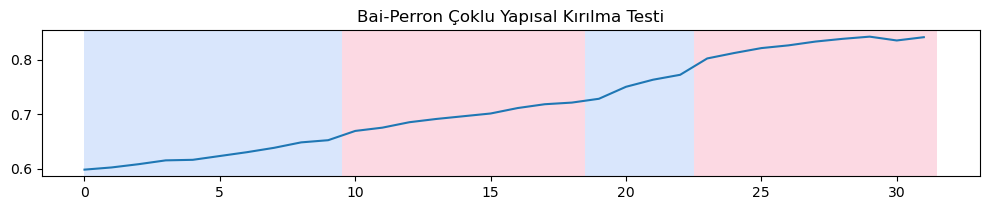

Tespit edilen kırılma noktaları (yıl pozisyonları): [10, 19, 23, 32]


In [15]:
import pandas as pd
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt

# Yalnızca bağımlı değişkenle test yapılacaksa (örnek olarak IGE):
signal = df['IGE'].values

# Model: "l2" (OLS tarzı) - max 5 kırılma noktası
model = "l2"
algo = rpt.KernelCPD(kernel="linear").fit(signal)
result = algo.predict(n_bkps=3)  # 3 kırılma noktası ara (örnek)

# Görselleştirme
rpt.display(signal, result)
plt.title("Bai-Perron Çoklu Yapısal Kırılma Testi")
plt.show()

# Kırılma noktalarını yazdır
print("Tespit edilen kırılma noktaları (yıl pozisyonları):", result)


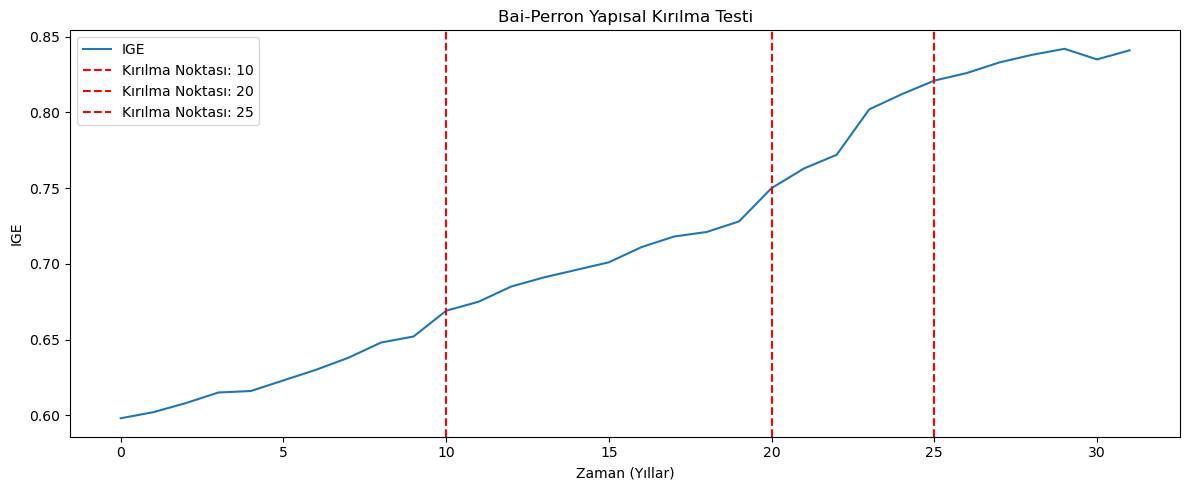

Tespit edilen kırılma noktaları (indeks bazında): [10, 20, 25]


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from ruptures import Binseg

# HDI serisini kullan
y = df['IGE'].dropna().values

# Bai-Perron için değişim noktası algılama
model = Binseg(model="l2").fit(y)
breaks = model.predict(n_bkps=3)  # Maksimum 3 kırılma noktası isteyebilirsin

# Görselleştirme
plt.figure(figsize=(12, 5))
plt.plot(y, label='IGE')
for bkpt in breaks[:-1]:  # Son değer veri uzunluğunu verir, onu atlıyoruz
    plt.axvline(bkpt, color='red', linestyle='--', label=f'Kırılma Noktası: {bkpt}')
plt.title("Bai-Perron Yapısal Kırılma Testi")
plt.xlabel("Zaman (Yıllar)")
plt.ylabel("IGE")
plt.legend()
plt.tight_layout()
plt.show()

# Kırılma noktalarının indekslerini yazdır
print("Tespit edilen kırılma noktaları (indeks bazında):", breaks[:-1])

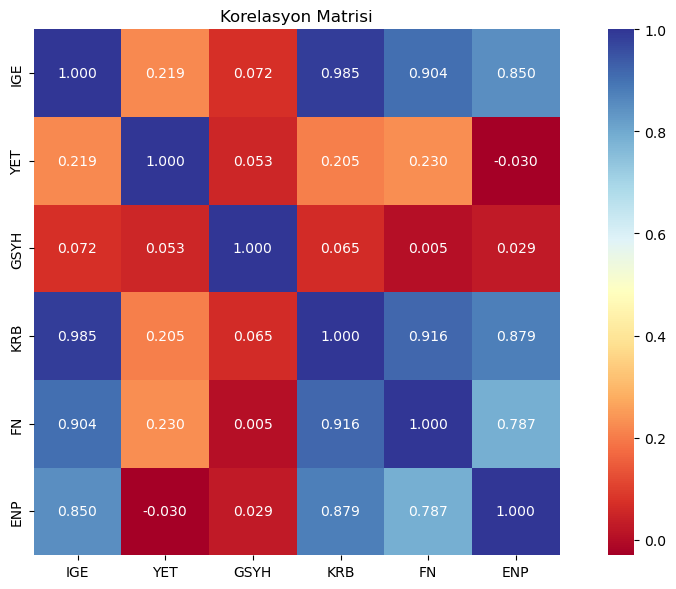

,IGE,YET,GSYH,KRB,FN,ENP
IGE,1.000000,0.219467,0.071889,0.985479,0.904066,0.850357
YET,0.219467,1.000000,0.052881,0.205439,0.230199,-0.030466
GSYH,0.071889,0.052881,1.000000,0.065056,0.004564,0.029344
KRB,0.985479,0.205439,0.065056,1.000000,0.915584,0.879119
FN,0.904066,0.230199,0.004564,0.915584,1.000000,0.786689
ENP,0.850357,-0.030466,0.029344,0.879119,0.786689,1.000000


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[['IGE', 'YET', 'GSYH', 'KRB', 'FN', 'ENP']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', fmt=".3f", square=True)
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

corr_matrix

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

X = df[['YET', 'GSYH', 'KRB', 'FN', 'ENP']]
X = add_constant(X)

# VIF 
vif_data = pd.DataFrame()
vif_data['Değişken'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


  Değişken        VIF
0    const  35.870512
1      YET   1.320688
2     GSYH   1.029616
3      KRB  11.719970
4       FN   6.407805
5      ENP   5.567191


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

X = df[['YET', 'GSYH', 'FN', 'ENP']]
X = add_constant(X)

# VIF 
vif_data = pd.DataFrame()
vif_data['Değişken'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

  Değişken        VIF
0    const  35.412547
1      YET   1.211843
2     GSYH   1.007082
3       FN   3.170382
4      ENP   3.007876


In [25]:
!pip install --upgrade statsmodels

In [27]:
from statsmodels.tsa.ardl import ardl_select_order, ARDL
import pandas as pd

df = pd.read_excel('tr_data.xlsx')
df['YIL'] = pd.to_datetime(df['YIL'], format='%Y')
df = df.set_index('YIL')
df.index = df.index.to_period('Y')
df = df[['IGE','YET','GSYH','FN','ENP']].dropna()
y = df['IGE']
exog = df[['YET','GSYH','FN','ENP']]

sel = ardl_select_order(endog=y,
                        exog=exog,
                        maxlag=2,
                        maxorder=2,
                        ic='aic')

print(sel.model)
ardl_model = sel.model.fit()
print(ardl_model.summary())

                              ARDL Model Results                              
Dep. Variable:                    IGE   No. Observations:                   32
Model:               ARDL(2, 2, 2, 0)   Log Likelihood                 120.676
Method:               Conditional MLE   S.D. of innovations              0.004
Date:                Mon, 09 Jun 2025   AIC                           -219.351
Time:                        01:20:03   BIC                           -203.938
Sample:                    12-31-1992   HQIC                          -214.420
                         - 12-31-2021                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0515      0.021      2.502      0.021       0.009       0.094
IGE.L1         1.1991      0.201      5.971      0.000       0.780       1.618
IGE.L2        -0.3014      0.197     -1.532      0.1

In [29]:
import pandas as pd
import statsmodels.api as sm
turkey = pd.read_excel('tr_data.xlsx')

turkey['YIL'] = pd.to_datetime(turkey['YIL'], format='%Y')
turkey = turkey.set_index('YIL')
turkey.index = turkey.index.to_period('Y')


p = 2  
q_dict = {'YET': None,  'GSYH': 2, 'FN': 2, 'ENP': 0}

df = turkey[['IGE'] + list(q_dict.keys())].copy()

df['L1_IGE'] = df['IGE'].shift(1)
for var, q in q_dict.items():
    df[f'L1_{var}'] = df[var].shift(1)
    df[f'd_{var}'] = df[var].diff()
df['d_IGE'] = df['IGE'].diff()

for i in range(1, p + 1):
    df[f'd_HDI_L{i}'] = df['d_IGE'].shift(i)
for var, q in q_dict.items():
    if q:
        for i in range(1, q + 1):
            df[f'd_{var}_L{i}'] = df[f'd_{var}'].shift(i)

df2 = df.dropna()

y = df2['d_IGE']
level_terms = ['L1_IGE'] + [f'L1_{v}' for v, q in q_dict.items() if q is not None]
diff_terms = [c for c in df2.columns if c.startswith('d_') and 'L' in c]
X = sm.add_constant(df2[level_terms + diff_terms])

# OLS ve F-testi
model = sm.OLS(y, X).fit()
hypotheses = ' = 0, '.join(level_terms) + ' = 0'
f_res = model.f_test(hypotheses)
f_stat = float(f_res.fvalue)

# Pesaran (2001) kritik değerleri (k=5 için)
# K = 3 için  Lower ≈ 3.23, Upper ≈ 4.35
lower_bound = 3.23
upper_bound = 4.35

print("=== Türkiye için ARDL Bounds Test Sonucu ===")
print("Test edilen level terimleri:", level_terms)
print(f"F-istatistiği = {f_stat:.3f}")
print(f"p-değeri      = {f_res.pvalue:.3f}")
print(f"Pesaran %5 Kritik Değerler → Lower = {lower_bound}, Upper = {upper_bound}")

if f_stat > upper_bound:
    print("Sonuç: F > Upper bound → Uzun dönem eşbütünleşme VAR.")
elif f_stat < lower_bound:
    print("Sonuç: F < Lower bound → Uzun dönem eşbütünleşme YOK.")
else:
    print("Sonuç: F sınırlar arasında → Kararsız (inconclusive).")


=== Türkiye için ARDL Bounds Test Sonucu ===
Test edilen level terimleri: ['L1_IGE', 'L1_GSYH', 'L1_FN', 'L1_ENP']
F-istatistiği = 2.118
p-değeri      = 0.121
Pesaran %5 Kritik Değerler → Lower = 3.23, Upper = 4.35
Sonuç: F < Lower bound → Uzun dönem eşbütünleşme YOK.


In [31]:
import pandas as pd
from statsmodels.tsa.api import VAR

df = pd.read_excel('tr_data.xlsx')
df['YIL'] = pd.to_datetime(df['YIL'], format='%Y')
df = df.set_index('YIL')
df.index = df.index.to_period('Y')

df = df[['IGE', 'GSYH', 'ENP']].dropna()

model = VAR(df)

lag_selection = model.select_order(maxlags=5)
print("\n=== Lag Seçimi (Dar Model) ===")
print(lag_selection.summary())

optimal_lag = lag_selection.aic
print(f"\nSeçilen Optimal Lag (AIC'ye göre): {optimal_lag}")

var_model = model.fit(optimal_lag)

print("\n=== Türkiye (Dar Model) VAR Sonuçları ===")
print(var_model.summary())



=== Lag Seçimi (Dar Model) ===
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -4.827      -4.683    0.008012      -4.784
1     -10.44*     -9.867*  2.935e-05*     -10.27*
2      -10.13      -9.122   4.135e-05      -9.830
3      -9.810      -8.370   6.134e-05      -9.382
4      -9.640      -7.768   8.445e-05      -9.083
5      -10.03      -7.728   7.503e-05      -9.347
-------------------------------------------------

Seçilen Optimal Lag (AIC'ye göre): 1

=== Türkiye (Dar Model) VAR Sonuçları ===
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 09, Jun, 2025
Time:                     01:20:20
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -10.0878
Nobs:                     31.0000    HQIC:                  -10.4619
Log l

In [33]:
import pandas as pd
from statsmodels.tsa.api import VAR

# Veriyi oku
df = pd.read_excel('tr_data.xlsx')

# Tarih kolonu düzenleniyor
df['YIL'] = pd.to_datetime(df['YIL'], format='%Y')
df = df.set_index('YIL')
df.index = df.index.to_period('Y')

# Kullanılacak değişkenleri seç
df = df[['IGE', 'YET', 'GSYH', 'FN', 'ENP']]

# GSYH I(0) olduğu için aynen kullanılır
# Diğer değişkenlerin birinci farkı alınır
df_diff = pd.DataFrame()
df_diff['d_IGE'] = df['IGE'].diff()
df_diff['d_YET'] = df['YET'].diff()
df_diff['GSYH'] = df['GSYH']  # Seviyede durağan
df_diff['d_FN'] = df['FN'].diff()
df_diff['d_ENP'] = df['ENP'].diff()

# İlk farklardan sonra oluşan eksik gözlemler atılır
df_diff = df_diff.dropna()

# VAR modelini oluştur
model = VAR(df_diff)

# Gecikme sayısı seçimi (AIC'ye göre)
lag_selection = model.select_order(maxlags=2)
print("\n=== Lag Seçimi (Farklar Alınmış Model) ===")
print(lag_selection.summary())

# AIC’ye göre optimal lag
optimal_lag = lag_selection.aic
print(f"\nSeçilen Optimal Lag (AIC'ye göre): {optimal_lag}")
# Modeli uygun lag ile kur
var_model = model.fit(optimal_lag)

# Sonuçları yazdır
print("\n=== VAR Model Sonuçları (Durağanlaştırılmış Verilerle) ===")
print(var_model.summary())




=== Lag Seçimi (Farklar Alınmış Model) ===
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -6.547*     -6.311*   0.001435*     -6.473*
1      -5.594      -4.180    0.003833      -5.151
2      -5.138      -2.544    0.007168      -4.325
-------------------------------------------------

Seçilen Optimal Lag (AIC'ye göre): 0

=== VAR Model Sonuçları (Durağanlaştırılmış Verilerle) ===
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 09, Jun, 2025
Time:                     01:20:28
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -6.61115
Nobs:                     31.0000    HQIC:                  -6.76704
Log likelihood:          -108.878    FPE:                 0.00106762
AIC:                     -6.84243    Det(Omega_mle):     

In [35]:
import pandas as pd
from statsmodels.tsa.api import VAR

# Veriyi oku ve tarih formatını ayarla
df = pd.read_excel('tr_data.xlsx')
df['YIL'] = pd.to_datetime(df['YIL'], format='%Y')
df = df.set_index('YIL')
df.index = df.index.to_period('Y')

# Kullanacağın değişkenleri seç
vars = ['IGE', 'YET', 'GSYH', 'FN', 'ENP']
df = df[vars].dropna()

# Değişkenlerin birinci farklarını al
df_diff = df.diff().dropna()
df_diff['GSYH'] = df['GSYH'].iloc[1:]  # fark almadan doğrudan eklenir
model = VAR(df_diff)

# Gözlem sayısına uygun şekilde maxlag=2
lag_selection = model.select_order(maxlags=2)
print("\n=== Lag Seçimi (Farklar Alınmış Model) ===")
print(lag_selection.summary())

# AIC'ye göre en iyi lag
optimal_lag = lag_selection.aic
print(f"\nAIC'ye göre en uygun gecikme: {optimal_lag}")
var_model = model.fit(optimal_lag)
print("\n=== VAR Model Sonuçları ===")
print(var_model.summary())



=== Lag Seçimi (Farklar Alınmış Model) ===
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -6.547*     -6.311*   0.001435*     -6.473*
1      -5.594      -4.180    0.003833      -5.151
2      -5.138      -2.544    0.007168      -4.325
-------------------------------------------------

AIC'ye göre en uygun gecikme: 0

=== VAR Model Sonuçları ===
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 09, Jun, 2025
Time:                     01:20:33
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -6.61115
Nobs:                     31.0000    HQIC:                  -6.76704
Log likelihood:          -108.878    FPE:                 0.00106762
AIC:                     -6.84243    Det(Omega_mle):     0.000910911
------------------------

In [43]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

# === 1. Veriyi hazırla ===
# df zaten aşağıdaki sütunlara sahip: ['IGE', 'YET', 'GSYH', 'FN', 'ENP']

# Serilerin birinci farkını al
df_diff = df.diff().dropna()

# Sütunları yeniden adlandır (d_ ile başlayacak şekilde)
df_diff = df_diff.rename(columns={
    'IGE': 'd_IGE',
    'YET': 'd_YET',
    'GSYH': 'd_GSYH',
    'FN': 'd_FN',
    'ENP': 'd_ENP'
})

# === 2. Granger testi yapılacak değişken çiftleri ===
test_pairs = [
    ('d_GSYH', 'd_IGE'),   # GSYH → IGE
    ('d_FN', 'd_IGE'),     # FN → IGE
    ('d_ENP', 'd_IGE'),    # ENP → IGE
    ('d_GSYH', 'd_FN'),    # GSYH → FN
    ('d_FN', 'd_GSYH'),    # FN → GSYH
]

# === 3. Testi uygula ===
results = []

for x, y in test_pairs:
    print(f"\nTesting whether {x} Granger-causes {y}")
    test_result = grangercausalitytests(df_diff[[y, x]], maxlag=1, verbose=False)
    
    # Lag=1 için F-testi p-değeri
    p_value = test_result[1][0]['ssr_ftest'][1]
    results.append((x, y, round(p_value, 4)))

# === 4. Sonuçları tablo olarak yazdır ===
granger_summary = pd.DataFrame(results, columns=["Cause", "Effect", "p-value"])
print("\n=== Granger Nedensellik Testi Sonuçları ===")
print(granger_summary)



Testing whether d_GSYH Granger-causes d_IGE

Testing whether d_FN Granger-causes d_IGE

Testing whether d_ENP Granger-causes d_IGE

Testing whether d_GSYH Granger-causes d_FN

Testing whether d_FN Granger-causes d_GSYH

=== Granger Nedensellik Testi Sonuçları ===
    Cause  Effect  p-value
0  d_GSYH   d_IGE   0.1518
1    d_FN   d_IGE   0.1990
2   d_ENP   d_IGE   0.6957
3  d_GSYH    d_FN   0.8664
4    d_FN  d_GSYH   0.0101


C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [45]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
from itertools import permutations

# === 1. Fark alınmış ve yeniden adlandırılmış veri çerçevesini hazırla ===
df_diff = df.diff().dropna()

df_diff = df_diff.rename(columns={
    'IGE': 'd_IGE',
    'YET': 'd_YET',
    'GSYH': 'd_GSYH',
    'FN': 'd_FN',
    'ENP': 'd_ENP'
})

# === 2. Tüm değişken çiftlerini oluştur (sıra önemli: X → Y) ===
variables = df_diff.columns.tolist()
test_pairs = list(permutations(variables, 2))  # Tüm yönlü kombinasyonlar

# === 3. Granger testi sonuçlarını F ve p ile birlikte topla ===
results = []

for cause, effect in test_pairs:
    try:
        # Testi uygula
        test_result = grangercausalitytests(df_diff[[effect, cause]], maxlag=1, verbose=False)
        
        # Lag = 1 için F-istatistiği ve p-değeri
        f_stat = test_result[1][0]['ssr_ftest'][0]
        p_value = test_result[1][0]['ssr_ftest'][1]

        results.append((cause, effect, round(f_stat, 4), round(p_value, 4)))

    except Exception as e:
        # Hata olursa None ekle
        results.append((cause, effect, None, None))
        print(f"Hata: {cause} → {effect} için test yapılamadı. Sebep: {e}")

# === 4. Sonuçları tabloya dök ===
granger_table = pd.DataFrame(results, columns=["Cause", "Effect", "F-stat", "p-value"])

# Anlamlı olanları filtrele (isteğe bağlı)
significant = granger_table[granger_table["p-value"] < 0.05]

# === 5. Sonuçları yazdır ===
print("\n=== Granger Nedensellik Testi Sonuçları (F ve p-değeri ile) ===")
print(granger_table)

print("\n=== Anlamlı Nedensellikler (p < 0.05) ===")
print(significant)



=== Granger Nedensellik Testi Sonuçları (F ve p-değeri ile) ===
     Cause  Effect  F-stat  p-value
0    d_IGE   d_YET  1.0740   0.3092
1    d_IGE  d_GSYH  1.2086   0.2813
2    d_IGE    d_FN  1.9483   0.1741
3    d_IGE   d_ENP  0.2121   0.6488
4    d_YET   d_IGE  1.9000   0.1794
5    d_YET  d_GSYH  0.0288   0.8666
6    d_YET    d_FN  0.4309   0.5171
7    d_YET   d_ENP  1.1275   0.2977
8   d_GSYH   d_IGE  2.1751   0.1518
9   d_GSYH   d_YET  0.9364   0.3418
10  d_GSYH    d_FN  0.0289   0.8664
11  d_GSYH   d_ENP  0.5453   0.4666
12    d_FN   d_IGE  1.7341   0.1990
13    d_FN   d_YET  0.0305   0.8626
14    d_FN  d_GSYH  7.6640   0.0101
15    d_FN   d_ENP  0.2189   0.6436
16   d_ENP   d_IGE  0.1563   0.6957
17   d_ENP   d_YET  0.0557   0.8151
18   d_ENP  d_GSYH  0.2268   0.6377
19   d_ENP    d_FN  0.0275   0.8695

=== Anlamlı Nedensellikler (p < 0.05) ===
   Cause  Effect  F-stat  p-value
14  d_FN  d_GSYH   7.664   0.0101


C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions shou

In [53]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

residuals = var_model.resid

# Breusch-Godfrey testi
for col in residuals.columns:
    print(f"\n=== Breusch-Godfrey Test: {col} için ===")
    
    y = residuals[col]
    X = sm.add_constant(residuals.shift(1).dropna())
    
    y = y.iloc[1:] 
   
    model = sm.OLS(y, X).fit()
    
    bg_test = acorr_breusch_godfrey(model, nlags=1)
    
    print(f"LM Statistiği: {bg_test[0]:.4f}")
    print(f"p-değeri: {bg_test[1]:.4f}")
    print(f"F-Statistiği: {bg_test[2]:.4f}")
    print(f"F p-değeri: {bg_test[3]:.4f}")
    
    if bg_test[1] > 0.05:
        print("Sonuç: H0 reddedilemedi → Otokorelasyon YOK.")
    else:
        print("Sonuç: H0 reddedildi → Otokorelasyon VAR.")





=== Breusch-Godfrey Test: IGE için ===
LM Statistiği: 0.0467
p-değeri: 0.8289
F-Statistiği: 0.0358
F p-değeri: 0.8515
Sonuç: H0 reddedilemedi → Otokorelasyon YOK.

=== Breusch-Godfrey Test: YET için ===
LM Statistiği: 0.7362
p-değeri: 0.3909
F-Statistiği: 0.5786
F p-değeri: 0.4546
Sonuç: H0 reddedilemedi → Otokorelasyon YOK.

=== Breusch-Godfrey Test: GSYH için ===
LM Statistiği: 0.0819
p-değeri: 0.7748
F-Statistiği: 0.0629
F p-değeri: 0.8042
Sonuç: H0 reddedilemedi → Otokorelasyon YOK.

=== Breusch-Godfrey Test: FN için ===
LM Statistiği: 0.1547
p-değeri: 0.6940
F-Statistiği: 0.1193
F p-değeri: 0.7330
Sonuç: H0 reddedilemedi → Otokorelasyon YOK.

=== Breusch-Godfrey Test: ENP için ===
LM Statistiği: 0.0505
p-değeri: 0.8223
F-Statistiği: 0.0387
F p-değeri: 0.8457
Sonuç: H0 reddedilemedi → Otokorelasyon YOK.


In [55]:
import statsmodels.stats.diagnostic as diag
import statsmodels.api as sm

residuals = var_model.resid

for col in residuals.columns:
    print(f"\n=== White Heteroskedasticity Test: {col} için ===")
    
    y = residuals[col]
    
    X = sm.add_constant(residuals.shift(1).dropna())
    y = y.iloc[1:] 

    model = sm.OLS(y, X).fit()

    white_test = diag.het_white(model.resid, model.model.exog)
    
    lm_stat = white_test[0]
    lm_pvalue = white_test[1]
    f_stat = white_test[2]
    f_pvalue = white_test[3]
    
    print(f"LM İstatistiği: {lm_stat:.4f}")
    print(f"LM p-değeri: {lm_pvalue:.4f}")
    print(f"F-İstatistiği: {f_stat:.4f}")
    print(f"F p-değeri: {f_pvalue:.4f}")

    if lm_pvalue > 0.05:
        print("Sonuç: H0 reddedilemedi → Homoskedastisite VAR (sabit varyans).")
    else:
        print("Sonuç: H0 reddedildi → Heteroskedastisite VAR (değişken varyans).")




=== White Heteroskedasticity Test: IGE için ===
LM İstatistiği: 5.5659
LM p-değeri: 0.9862
F-İstatistiği: 0.2126
F p-değeri: 0.9974
Sonuç: H0 reddedilemedi → Homoskedastisite VAR (sabit varyans).

=== White Heteroskedasticity Test: YET için ===
LM İstatistiği: 12.6087
LM p-değeri: 0.6325
F-İstatistiği: 0.6767
F p-değeri: 0.7691
Sonuç: H0 reddedilemedi → Homoskedastisite VAR (sabit varyans).

=== White Heteroskedasticity Test: GSYH için ===
LM İstatistiği: 6.7871
LM p-değeri: 0.9633
F-İstatistiği: 0.2729
F p-değeri: 0.9912
Sonuç: H0 reddedilemedi → Homoskedastisite VAR (sabit varyans).

=== White Heteroskedasticity Test: FN için ===
LM İstatistiği: 13.8296
LM p-değeri: 0.5385
F-İstatistiği: 0.7982
F p-değeri: 0.6656
Sonuç: H0 reddedilemedi → Homoskedastisite VAR (sabit varyans).

=== White Heteroskedasticity Test: ENP için ===
LM İstatistiği: 20.9434
LM p-değeri: 0.1386
F-İstatistiği: 2.1583
F p-değeri: 0.0793
Sonuç: H0 reddedilemedi → Homoskedastisite VAR (sabit varyans).


In [57]:
from scipy.stats import jarque_bera, skew, kurtosis
import statsmodels.api as sm

residuals = var_model.resid

for col in residuals.columns:
    print(f"\n=== Jarque-Bera Normalite Testi: {col} için ===")
    
    resid = residuals[col]

    jb_stat, jb_pvalue = jarque_bera(resid)

    # skewness ve kurtosis
    skewness = skew(resid)
    kurt = kurtosis(resid, fisher=False)

    print(f"JB İstatistiği: {jb_stat:.4f}")
    print(f"p-değeri: {jb_pvalue:.4f}")
    print(f"Çarpıklık (Skewness): {skewness:.4f}")
    print(f"Basıklık (Kurtosis): {kurt:.4f}")

    if jb_pvalue > 0.05:
        print("Sonuç: H0 reddedilemedi → Artıklar normal dağılıyor.")
    else:
        print("Sonuç: H0 reddedildi → Artıklar normal dağılmıyor.")



=== Jarque-Bera Normalite Testi: IGE için ===
JB İstatistiği: 33.7089
p-değeri: 0.0000
Çarpıklık (Skewness): 1.4164
Basıklık (Kurtosis): 7.2511
Sonuç: H0 reddedildi → Artıklar normal dağılmıyor.

=== Jarque-Bera Normalite Testi: YET için ===
JB İstatistiği: 0.6414
p-değeri: 0.7256
Çarpıklık (Skewness): 0.3051
Basıklık (Kurtosis): 2.6474
Sonuç: H0 reddedilemedi → Artıklar normal dağılıyor.

=== Jarque-Bera Normalite Testi: GSYH için ===
JB İstatistiği: 3.5977
p-değeri: 0.1655
Çarpıklık (Skewness): -0.8297
Basıklık (Kurtosis): 3.1787
Sonuç: H0 reddedilemedi → Artıklar normal dağılıyor.

=== Jarque-Bera Normalite Testi: FN için ===
JB İstatistiği: 0.1438
p-değeri: 0.9306
Çarpıklık (Skewness): 0.0053
Basıklık (Kurtosis): 2.6665
Sonuç: H0 reddedilemedi → Artıklar normal dağılıyor.

=== Jarque-Bera Normalite Testi: ENP için ===
JB İstatistiği: 1020.2459
p-değeri: 0.0000
Çarpıklık (Skewness): 5.2947
Basıklık (Kurtosis): 29.0333
Sonuç: H0 reddedildi → Artıklar normal dağılmıyor.


AttributeError: module 'statsmodels.graphics.api' has no attribute 'plot_cusum'

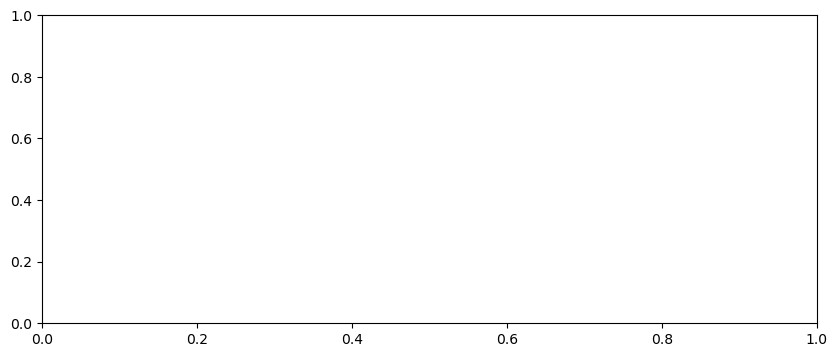

In [65]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
for col in var_model.resid.columns:
    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_subplot(111)
    
    sm.graphics.plot_cusum(var_model.resid[col], ax=ax, line_kw={'color': 'blue'})
    
    # Yaklaşık kritik sınırlar (Brown-Durbin-Evans)
    plt.axhline(0.948, color='red', linestyle='--', label='Üst Kritik Sınır (+0.95)')
    plt.axhline(-0.948, color='red', linestyle='--', label='Alt Kritik Sınır (−0.95)')
    
    plt.title(f"CUSUM Testi – {col}")
    plt.legend()
    plt.grid(True)
    plt.show()
for col in var_model.resid.columns:
    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_subplot(111)
    
    sm.graphics.plot_cusum(var_model.resid[col], ax=ax, squared=True, line_kw={'color': 'blue'})
    
    # Yaklaşık kritik sınırlar (Brown-Durbin-Evans)
    plt.axhline(0.462, color='red', linestyle='--', label='Üst Kritik Sınır (+0.46)')
    plt.axhline(-0.462, color='red', linestyle='--', label='Alt Kritik Sınır (−0.46)')
    
    plt.title(f"CUSUMQ Testi – {col}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [77]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import recursive_olsresiduals
import matplotlib.pyplot as plt

# Bağımlı ve bağımsız değişkenleri ayarla
y = df['IGE']
X = sm.add_constant(df[['GSYH', 'FN', 'ENP', 'YET']])

# Daha büyük skip değeri ver (örneğin 15)
recres = recursive_olsresiduals(sm.OLS(y, X).fit(), skip=15)

# Grafik çiz
plt.figure(figsize=(10, 4))
plt.plot(recres[3], label="CUSUM", color='blue')  # cumulative sum
plt.axhline(0.95, color='red', linestyle='--', label='Kritik Sınır (+)')
plt.axhline(-0.95, color='red', linestyle='--', label='Kritik Sınır (−)')
plt.title("CUSUM Testi – IGE")
plt.xlabel("Zaman")
plt.ylabel("Kümülatif Artıklar")
plt.legend()
plt.grid(True)
plt.show()


ValueError: "The initial regressor matrix, x[:skip], issingular. You must use a value of
skip large enough to ensure that the first OLS estimator is well-defined.


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.regression.recursive_ls import RecursiveLS
for col in var_model.resid.columns:
    print(f"=== CUSUM ve CUSUMQ: {col} ===")
    
    # Recursive LS modeli tanımla
    model = RecursiveLS(df[col], exog=np.ones(len(df)))
    results = model.fit()

    # Recursive residual'lar ve standardize edilmiş halleri
    rec_resid = results.recursive_resid
    std_rec_resid = rec_resid / np.std(rec_resid)

    # CUSUM hesapla
    cusum = np.cumsum(std_rec_resid)

    # CUSUMQ hesapla
    cusum_sq = np.cumsum(std_rec_resid**2)

    # Gözlem sayısı
    t = np.arange(len(cusum))

    # --- CUSUM ---
    plt.figure(figsize=(10, 4))
    plt.plot(t, cusum, label="CUSUM", color='blue')
    plt.axhline(0.948 * np.sqrt(len(cusum)), color='red', linestyle='--', label="Kritik Sınır (+)")
    plt.axhline(-0.948 * np.sqrt(len(cusum)), color='red', linestyle='--', label="Kritik Sınır (-)")
    plt.title(f"CUSUM Testi – {col}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- CUSUMQ ---
    plt.figure(figsize=(10, 4))
    plt.plot(t, cusum_sq, label="CUSUMQ", color='blue')
    plt.axhline(0.462 * len(cusum), color='red', linestyle='--', label="Kritik Sınır (+)")
    plt.axhline(-0.462 * len(cusum), color='red', linestyle='--', label="Kritik Sınır (-)")
    plt.title(f"CUSUMQ Testi – {col}")
    plt.legend()
    plt.grid(True)
    plt.show()


=== CUSUM ve CUSUMQ: IGE ===


AttributeError: 'RecursiveLSResults' object has no attribute 'recursive_resid'

=== CUSUM Testi: IGE ===


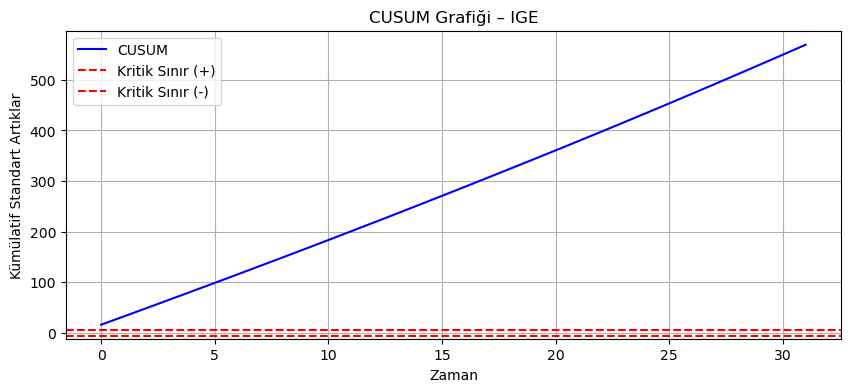

=== CUSUM Testi: YET ===


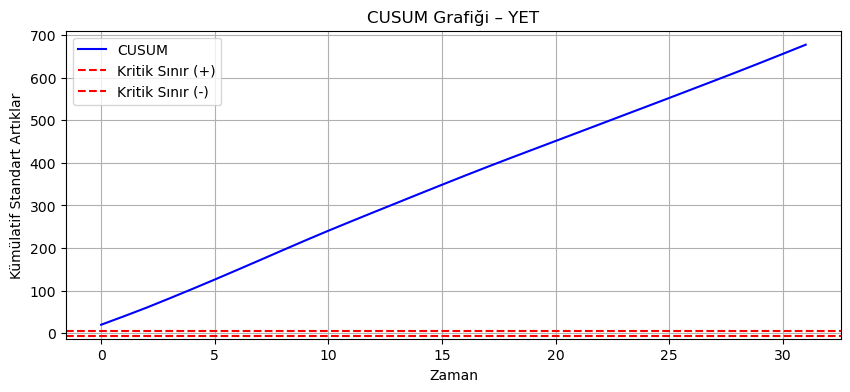

=== CUSUM Testi: GSYH ===


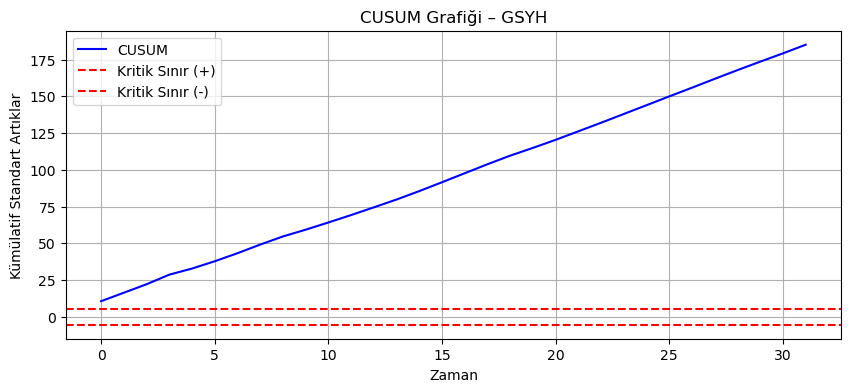

=== CUSUM Testi: FN ===


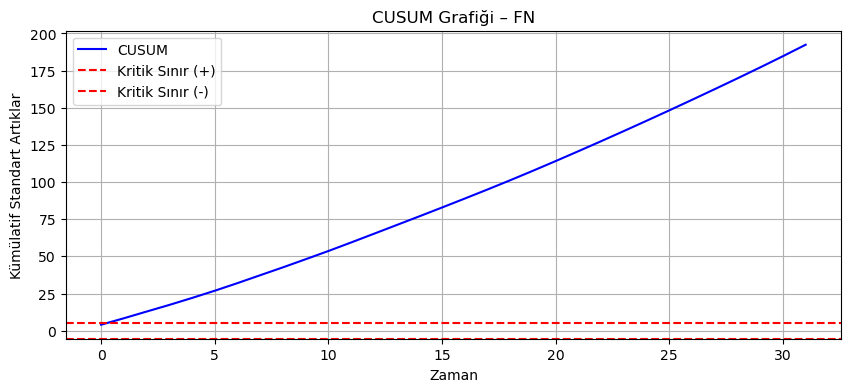

=== CUSUM Testi: ENP ===


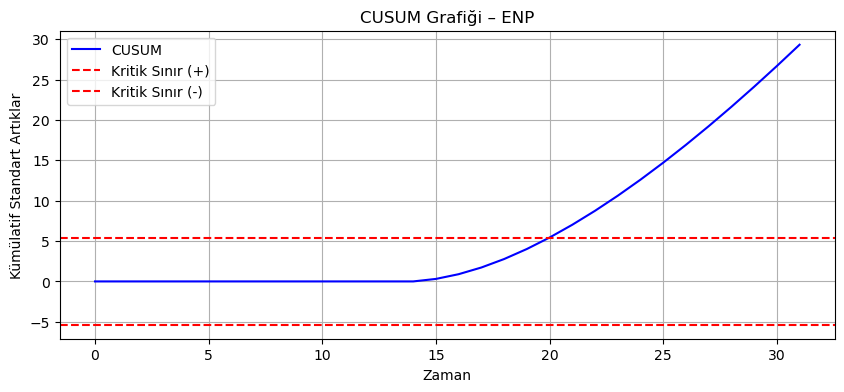

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.recursive_ls import RecursiveLS

# Gözlem sayısını almak için
n_obs = df.shape[0]

# CUSUM grafikleri için
for col in var_model.resid.columns:
    print(f"=== CUSUM Testi: {col} ===")
    
    # Recursive LS modelini sabit terim ile kur
    model = RecursiveLS(endog=df[col], exog=np.ones(n_obs))
    results = model.fit()

    # Recursive residual'ları ve standardize hali
    rec_resid = results.filtered_state[0]  # Bu recursive residual yerine geçer
    std_rec_resid = rec_resid / np.std(rec_resid)

    # CUSUM hesapla
    cusum = np.cumsum(std_rec_resid)

    # Zaman ekseni
    t = np.arange(len(cusum))

    # Grafik çiz
    plt.figure(figsize=(10, 4))
    plt.plot(t, cusum, label='CUSUM', color='blue')
    plt.axhline(0.948 * np.sqrt(n_obs), color='red', linestyle='--', label='Kritik Sınır (+)')
    plt.axhline(-0.948 * np.sqrt(n_obs), color='red', linestyle='--', label='Kritik Sınır (-)')
    plt.title(f"CUSUM Grafiği – {col}")
    plt.xlabel('Zaman')
    plt.ylabel('Kümülatif Standart Artıklar')
    plt.legend()
    plt.grid(True)
    plt.show()


In [59]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import recursive_olsresiduals
import statsmodels.api as sm

residuals = var_model.resid

for col in residuals.columns:
    print(f"\n=== {col} için CUSUM Grafiği ===")

    y = residuals[col]
    
    X = sm.add_constant(residuals.shift(1).dropna())
    y = y.iloc[1:]  

    ols_model = sm.OLS(y, X).fit()

    recresid = recursive_olsresiduals(ols_model)

    plt.figure(figsize=(10,6))
    plt.plot(recresid[3], label="CUSUM")
    plt.plot(recresid[4], 'r--', label="5% Alt Sınır")
    plt.plot(recresid[5], 'r--', label="5% Üst Sınır")
    plt.title(f"{col} için CUSUM Grafiği")
    plt.xlabel("Gözlem")
    plt.ylabel("Kümülatif Artıklar")
    plt.legend()
    plt.show()



=== IGE için CUSUM Grafiği ===


ValueError: "The initial regressor matrix, x[:skip], issingular. You must use a value of
skip large enough to ensure that the first OLS estimator is well-defined.


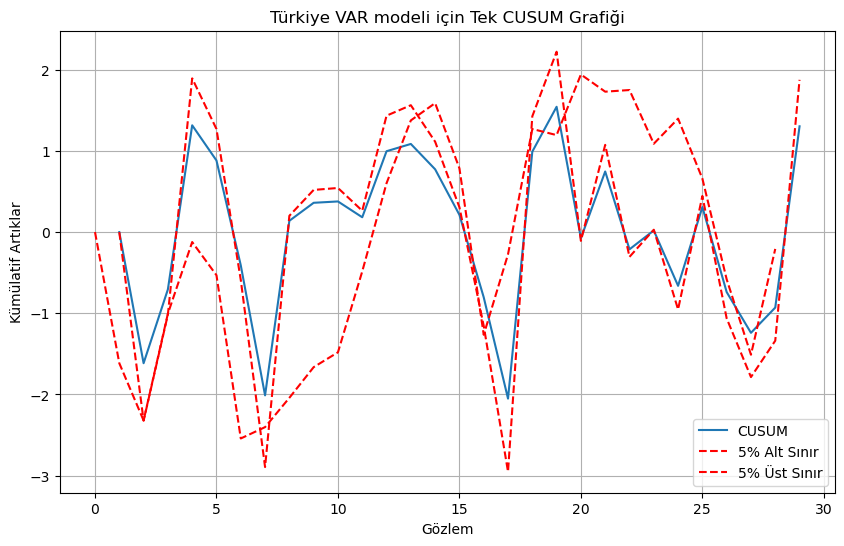

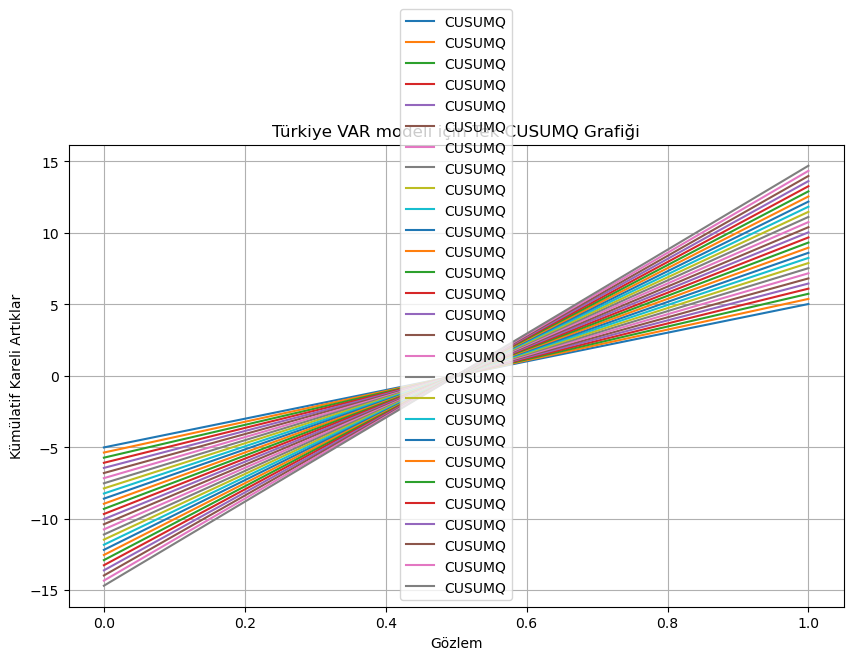

In [173]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import recursive_olsresiduals
import statsmodels.api as sm

residuals = var_model.resid

combined_resid = residuals.mean(axis=1)

y = combined_resid

X = sm.add_constant(y.shift(1).dropna())
y = y.iloc[1:]
ols_model = sm.OLS(y, X).fit()

recresid = recursive_olsresiduals(ols_model)

# CUSUM Grafiği
plt.figure(figsize=(10,6))
plt.plot(recresid[3], label="CUSUM")
plt.plot(recresid[4], 'r--', label="5% Alt Sınır")
plt.plot(recresid[5], 'r--', label="5% Üst Sınır")
plt.title("Türkiye VAR modeli için Tek CUSUM Grafiği")
plt.xlabel("Gözlem")
plt.ylabel("Kümülatif Artıklar")
plt.legend()
plt.grid(True)
plt.show()

# CUSUMQ Grafiği
plt.figure(figsize=(10,6))
plt.plot(recresid[6], label="CUSUMQ")
plt.title("Türkiye VAR modeli için Tek CUSUMQ Grafiği")
plt.xlabel("Gözlem")
plt.ylabel("Kümülatif Kareli Artıklar")
plt.legend()
plt.grid(True)
plt.show()


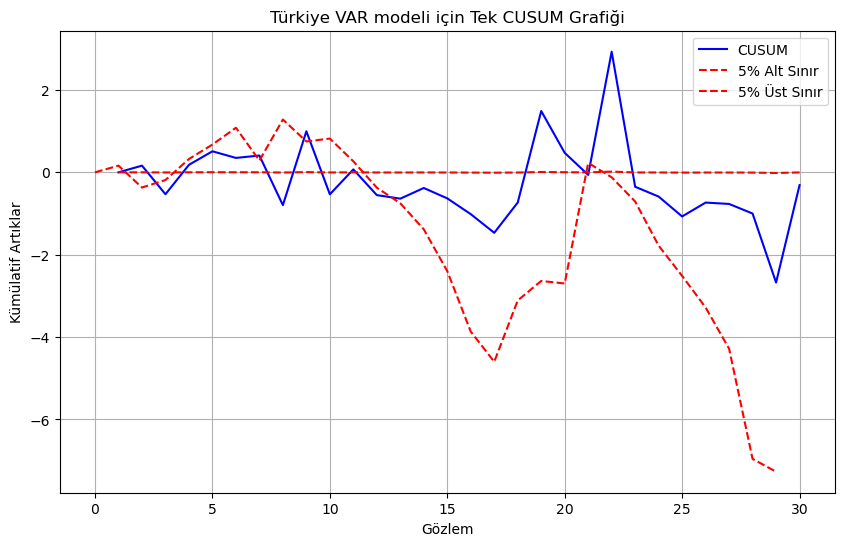

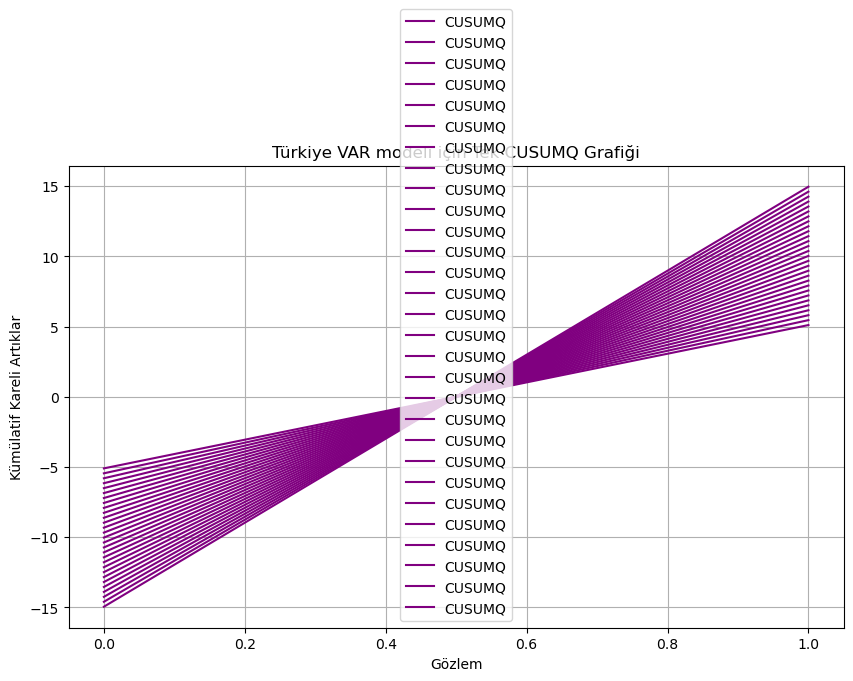

In [175]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import recursive_olsresiduals
import statsmodels.api as sm

residuals = var_model.resid

y = residuals['IGE']

X = sm.add_constant(np.arange(len(y)))

ols_model = sm.OLS(y, X).fit()

recresid = recursive_olsresiduals(ols_model)

# CUSUM Grafiği
plt.figure(figsize=(10,6))
plt.plot(recresid[3], label="CUSUM", color="blue")
plt.plot(recresid[4], 'r--', label="5% Alt Sınır")
plt.plot(recresid[5], 'r--', label="5% Üst Sınır")
plt.title("Türkiye VAR modeli için Tek CUSUM Grafiği")
plt.xlabel("Gözlem")
plt.ylabel("Kümülatif Artıklar")
plt.legend()
plt.grid(True)
plt.show()

# CUSUMQ Grafiği 
plt.figure(figsize=(10,6))
plt.plot(recresid[6], label="CUSUMQ", color="purple")
plt.title("Türkiye VAR modeli için Tek CUSUMQ Grafiği")
plt.xlabel("Gözlem")
plt.ylabel("Kümülatif Kareli Artıklar")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


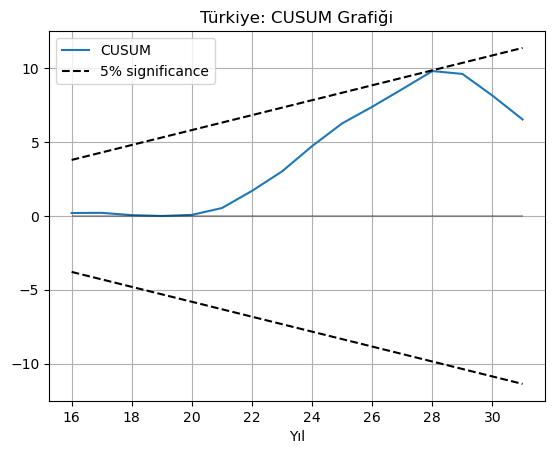

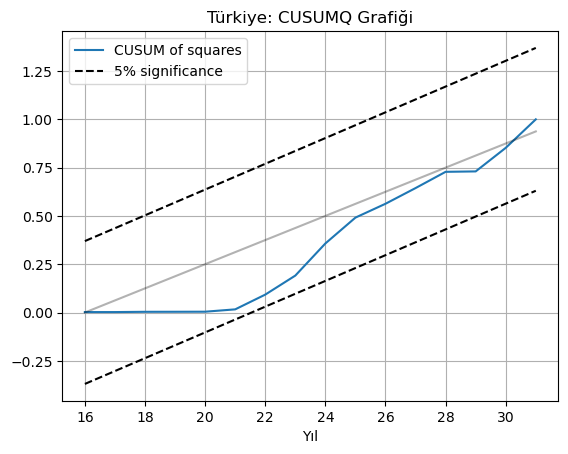

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_excel('tr_data.xlsx', index_col=0)

y = df['IGE']
X = sm.add_constant(df[['YET', 'GSYH', 'FN', 'ENP']])

# Recursive Least Squares
mod = sm.RecursiveLS(y, X)
res = mod.fit()

#CUSUM grafiği
res.plot_cusum()
plt.title('Türkiye: CUSUM Grafiği')
plt.xlabel('Yıl')
plt.grid(True)
plt.show()

# CUSUMQ grafiği
res.plot_cusum_squares()
plt.title('Türkiye: CUSUMQ Grafiği')
plt.xlabel('Yıl')
plt.grid(True)
plt.show()





C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


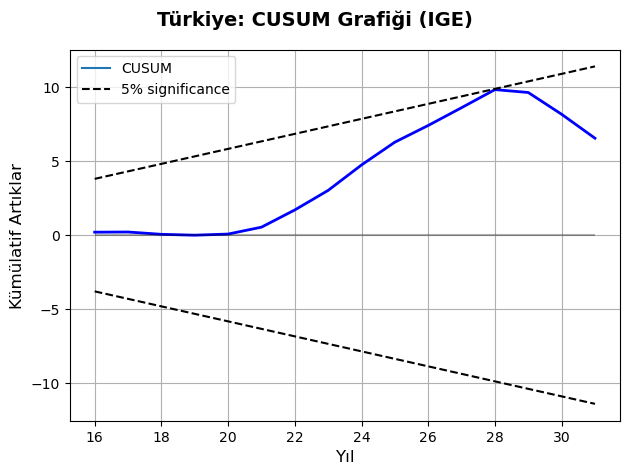

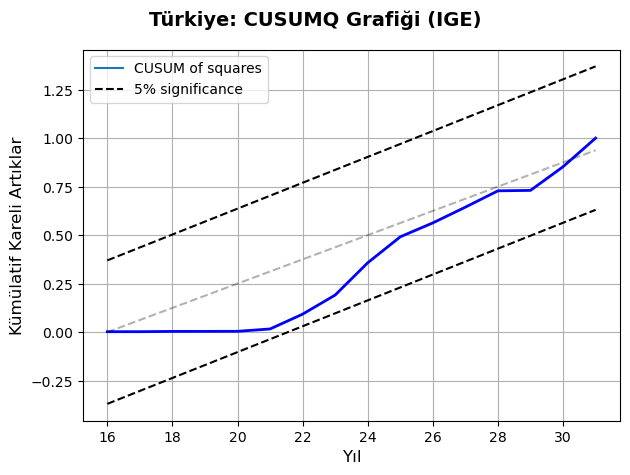

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Veri yükleme
df = pd.read_excel('tr_data.xlsx', index_col=0)

# Model kur
y = df['IGE']
X = sm.add_constant(df[['YET', 'GSYH', 'FN', 'ENP']])

mod = sm.RecursiveLS(y, X)
res = mod.fit()

# CUSUM grafiği
fig1 = res.plot_cusum()
fig1.suptitle('Türkiye: CUSUM Grafiği (IGE)', fontsize=14, fontweight='bold')
ax1 = fig1.axes[0]
ax1.set_xlabel("Yıl", fontsize=12)
ax1.set_ylabel("Kümülatif Artıklar", fontsize=12)
ax1.grid(True)
ax1.lines[0].set_color('blue')  # CUSUM çizgisi
ax1.lines[0].set_linewidth(2)
ax1.lines[1].set_color('black')  # Üst %5 sınır
ax1.lines[1].set_linestyle('--')
ax1.lines[2].set_color('black')  # Alt %5 sınır
ax1.lines[2].set_linestyle('--')
plt.tight_layout()
plt.show()

# CUSUMQ grafiği
fig2 = res.plot_cusum_squares()
fig2.suptitle('Türkiye: CUSUMQ Grafiği (IGE)', fontsize=14, fontweight='bold')
ax2 = fig2.axes[0]
ax2.set_xlabel("Yıl", fontsize=12)
ax2.set_ylabel("Kümülatif Kareli Artıklar", fontsize=12)
ax2.grid(True)
ax2.lines[0].set_color('blue')  # CUSUMQ çizgisi
ax2.lines[0].set_linewidth(2)
ax2.lines[1].set_color('black')  # Üst %5 sınır
ax2.lines[1].set_linestyle('--')
ax2.lines[2].set_color('black')  # Alt %5 sınır
ax2.lines[2].set_linestyle('--')
plt.tight_layout()
plt.show()


C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


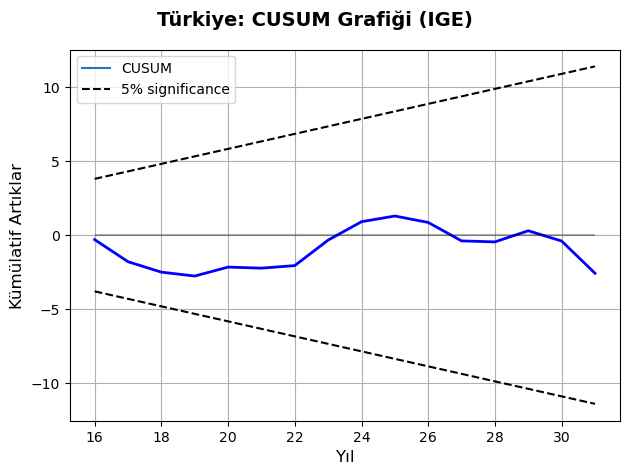

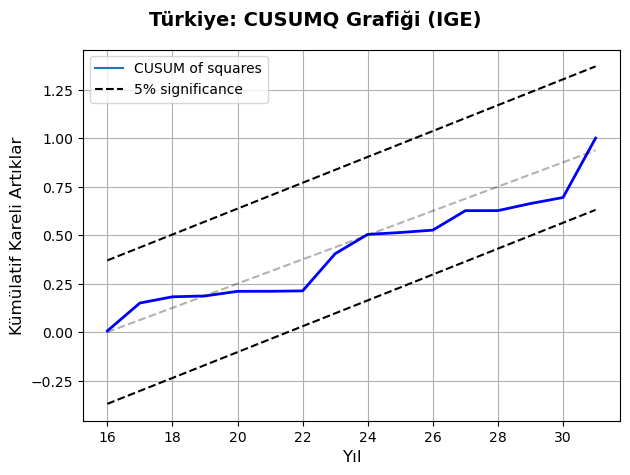

C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


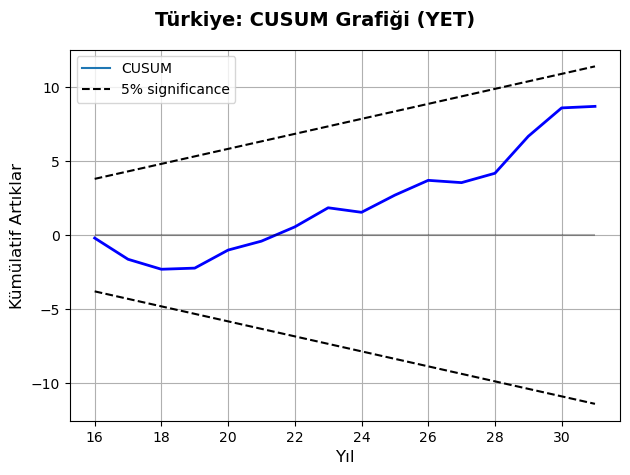

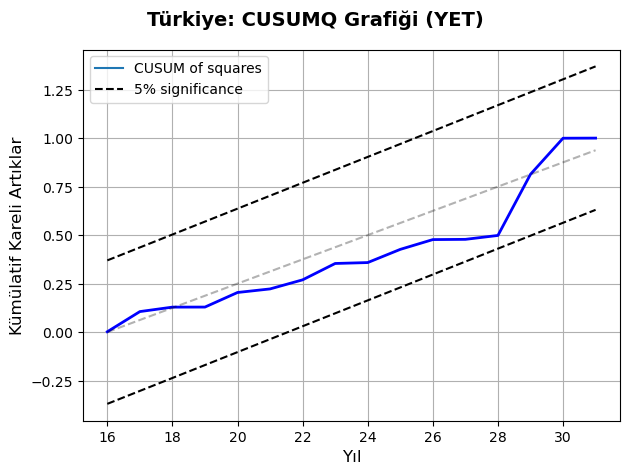

C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


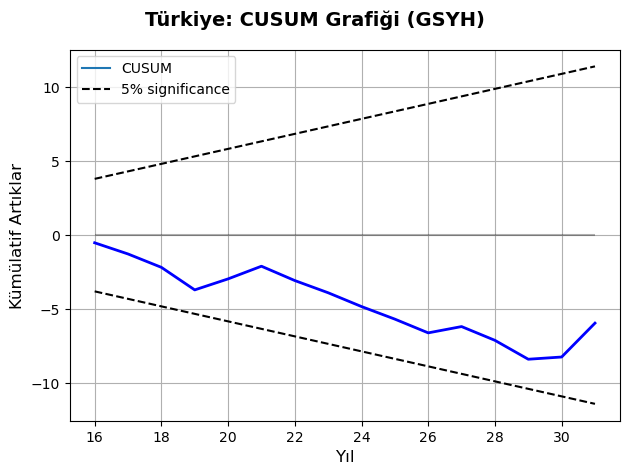

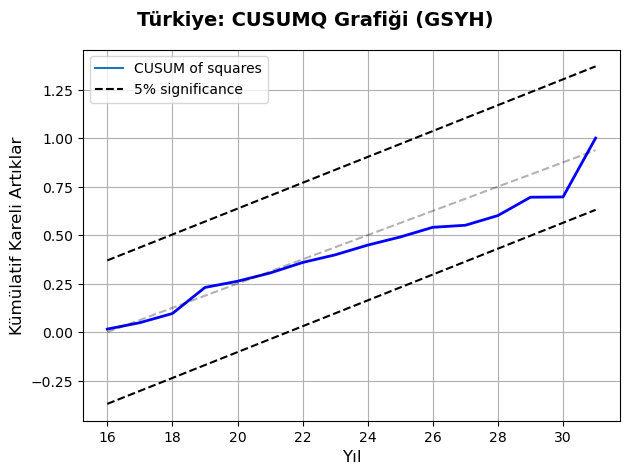

C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


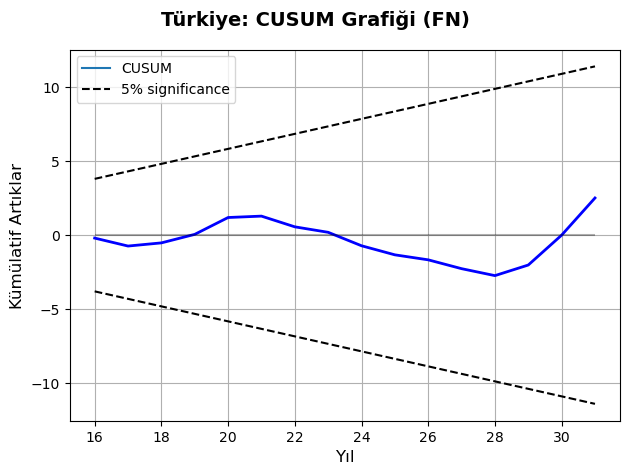

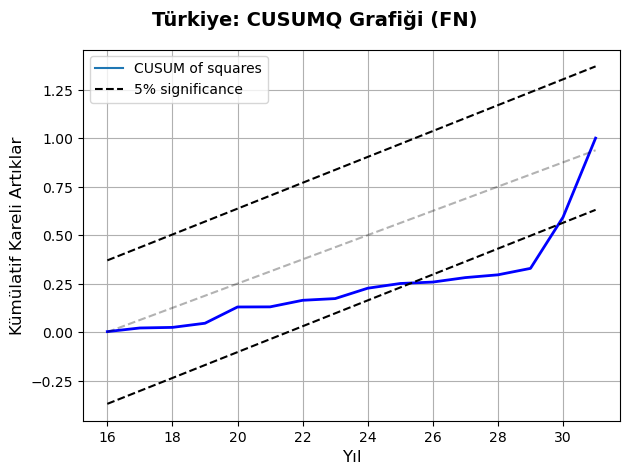

C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1762: RuntimeWarning: invalid value encountered in scalar divide
  self.scale = np.sum(scale_obs[d:]) / nobs_k_endog
C:\Users\nisak\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\nisak\anaconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\nisak\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(r

IndexError: index 32 is out of bounds for axis 0 with size 32

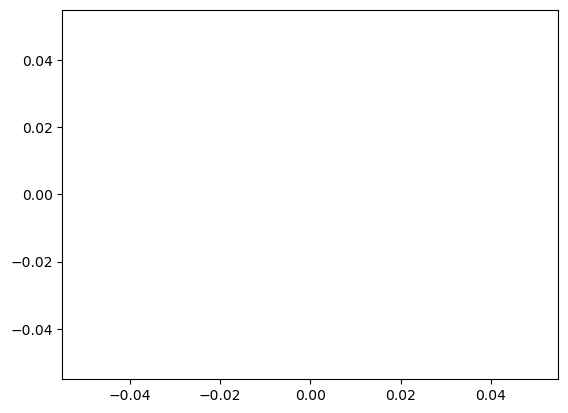

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Veriyi yükle
df = pd.read_excel('tr_data.xlsx', index_col=0)

# Tüm değişkenleri sırayla ele alalım
degiskenler = ['IGE', 'YET', 'GSYH', 'FN', 'ENP']

for target in degiskenler:
    # Bağımlı değişken
    y = df[target]

    # Bağımsız değişkenler (diğerleri)
    X = df.drop(columns=[target])
    X = sm.add_constant(X)

    # Recursive Least Squares modeli
    mod = sm.RecursiveLS(y, X)
    res = mod.fit()

    # --- CUSUM grafiği ---
    fig1 = res.plot_cusum()
    fig1.suptitle(f'Türkiye: CUSUM Grafiği ({target})', fontsize=14, fontweight='bold')
    ax1 = fig1.axes[0]
    ax1.set_xlabel("Yıl", fontsize=12)
    ax1.set_ylabel("Kümülatif Artıklar", fontsize=12)
    ax1.grid(True)
    ax1.lines[0].set_color('blue')
    ax1.lines[0].set_linewidth(2)
    ax1.lines[1].set_color('black')
    ax1.lines[1].set_linestyle('--')
    ax1.lines[2].set_color('black')
    ax1.lines[2].set_linestyle('--')
    plt.tight_layout()
    plt.show()

    # --- CUSUMQ grafiği ---
    fig2 = res.plot_cusum_squares()
    fig2.suptitle(f'Türkiye: CUSUMQ Grafiği ({target})', fontsize=14, fontweight='bold')
    ax2 = fig2.axes[0]
    ax2.set_xlabel("Yıl", fontsize=12)
    ax2.set_ylabel("Kümülatif Kareli Artıklar", fontsize=12)
    ax2.grid(True)
    ax2.lines[0].set_color('blue')
    ax2.lines[0].set_linewidth(2)
    ax2.lines[1].set_color('black')
    ax2.lines[1].set_linestyle('--')
    ax2.lines[2].set_color('black')
    ax2.lines[2].set_linestyle('--')
    plt.tight_layout()
    plt.show()


C:\Users\nisak\AppData\Local\Temp\ipykernel_5560\2935792775.py:9: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.index = pd.date_range(start='1990', periods=len(df), freq='Y')  # Yıllık indeks


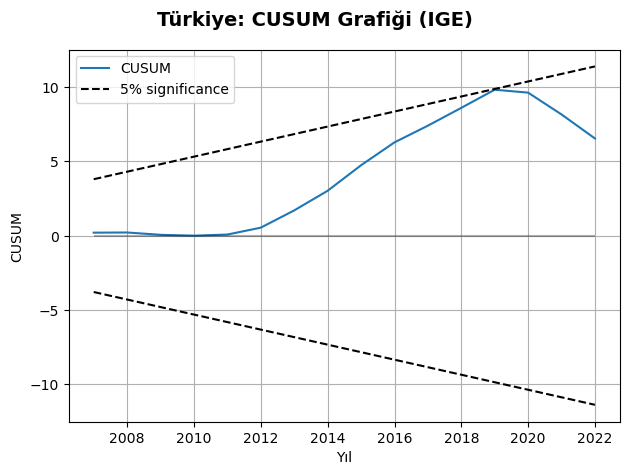

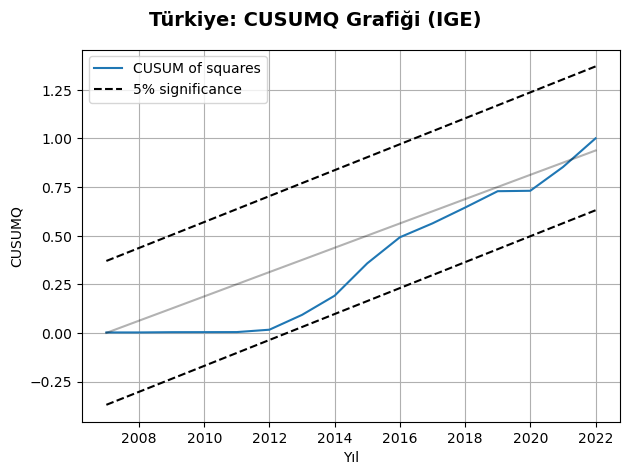

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Veriyi yükle
df = pd.read_excel('tr_data.xlsx', index_col=0)

# Yıllık frekans bilgisi ekle (index datetime değilse)
df.index = pd.date_range(start='1990', periods=len(df), freq='Y')  # Yıllık indeks

# Bağımlı değişken
y = df['IGE']

# Bağımsız değişkenler
X = sm.add_constant(df[['YET', 'GSYH', 'FN', 'ENP']])

# Recursive Least Squares
mod = sm.RecursiveLS(y, X)
res = mod.fit()

# CUSUM grafiği
fig1 = res.plot_cusum()
fig1.suptitle('Türkiye: CUSUM Grafiği (IGE)', fontsize=14, fontweight='bold')
ax1 = fig1.axes[0]
ax1.set_xlabel("Yıl")
ax1.set_ylabel("CUSUM")
ax1.grid(True)
plt.tight_layout()
plt.show()

# CUSUMQ grafiği
fig2 = res.plot_cusum_squares()
fig2.suptitle('Türkiye: CUSUMQ Grafiği (IGE)', fontsize=14, fontweight='bold')
ax2 = fig2.axes[0]
ax2.set_xlabel("Yıl")
ax2.set_ylabel("CUSUMQ")
ax2.grid(True)
plt.tight_layout()
plt.show()



--- CUSUM Testi: IGE ---


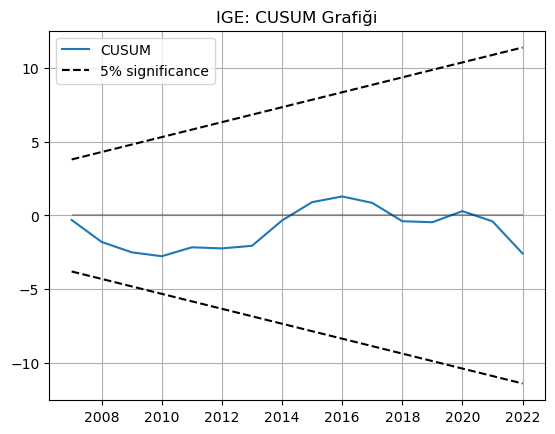

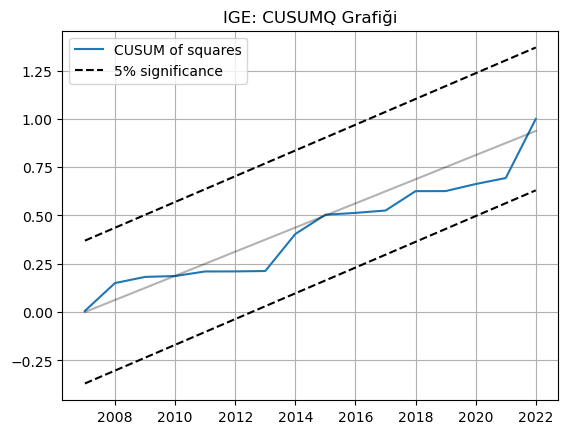


--- CUSUM Testi: YET ---


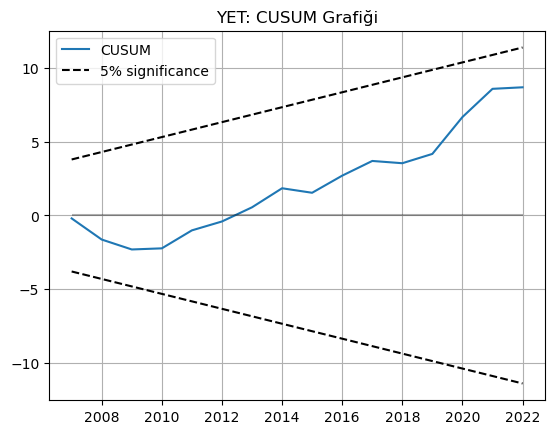

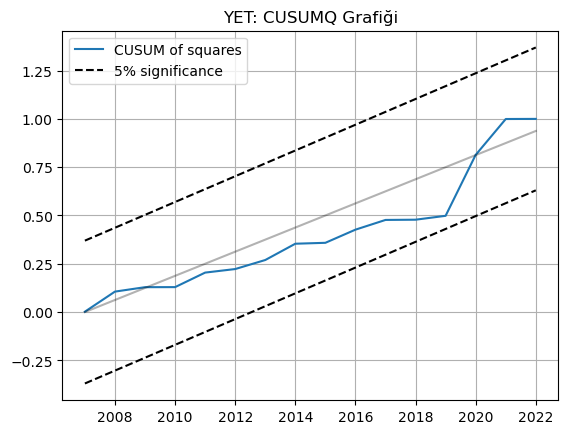


--- CUSUM Testi: GSYH ---


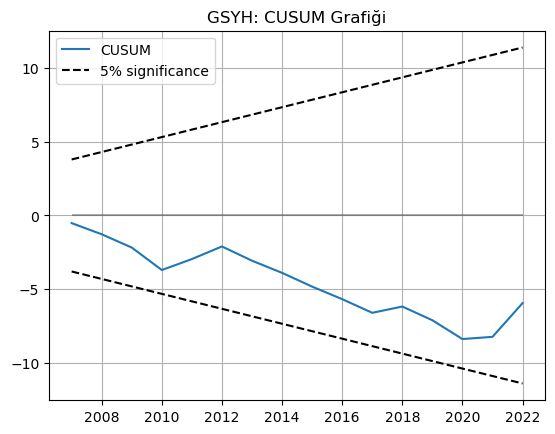

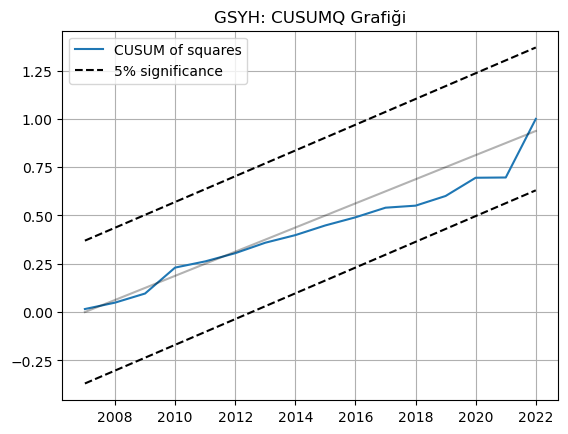


--- CUSUM Testi: KRB ---


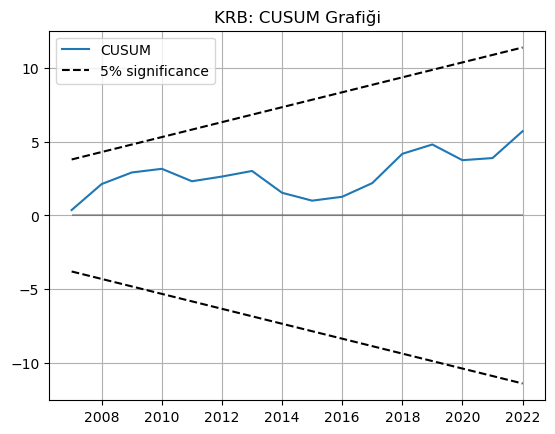

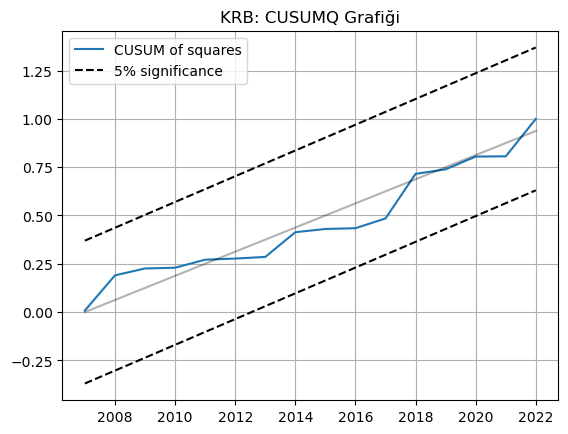


--- CUSUM Testi: FN ---


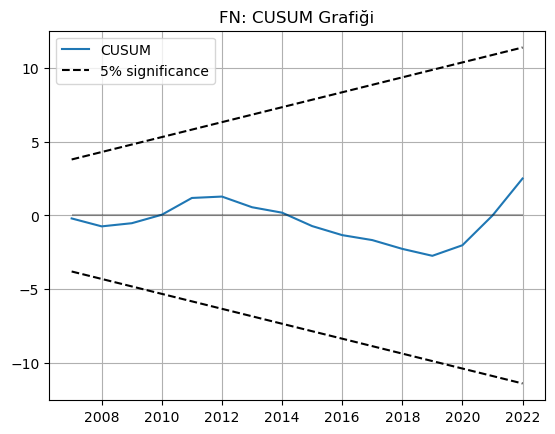

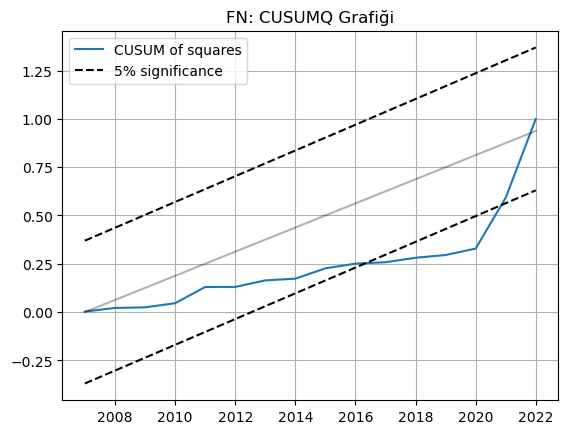


--- CUSUM Testi: ENP ---
ENP için hata oluştu: index 32 is out of bounds for axis 0 with size 32


C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1762: RuntimeWarning: invalid value encountered in scalar divide
  self.scale = np.sum(scale_obs[d:]) / nobs_k_endog
C:\Users\nisak\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\nisak\anaconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\nisak\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


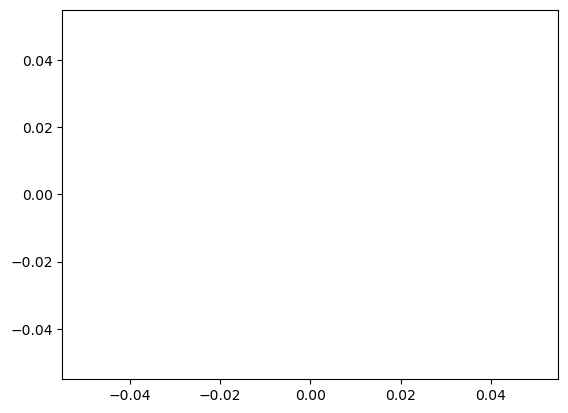

In [103]:
from statsmodels.regression.recursive_ls import RecursiveLS

for col in df.columns:
    y = df[col]
    X = sm.add_constant(df.drop(columns=[col]))

    try:
        mod = RecursiveLS(y, X)
        res = mod.fit()

        print(f"\n--- CUSUM Testi: {col} ---")
        res.plot_cusum()
        plt.title(f'{col}: CUSUM Grafiği')
        plt.grid(True)
        plt.show()

        res.plot_cusum_squares()
        plt.title(f'{col}: CUSUMQ Grafiği')
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"{col} için hata oluştu: {e}")


In [109]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset

# Veri setini yükle
df = pd.read_excel('tr_data.xlsx', index_col=0)

# Bağımlı ve bağımsız değişkenleri tanımla
y = df['IGE']
X = sm.add_constant(df[['YET', 'GSYH', 'FN', 'ENP']])  # Modelin bağımsız değişkenleri

# OLS modeli kur
model = sm.OLS(y, X).fit()

# Ramsey RESET testi (varsayılan olarak ikinci dereceden polinom ekler)
reset_result = linear_reset(model, power=2, use_f=True)

# Sonuçları yazdır
print("=== Ramsey RESET Testi ===")
print(f"F-istatistiği: {reset_result.fvalue:.4f}")
print(f"p-değeri: {reset_result.pvalue:.4f}")

if reset_result.pvalue > 0.05:
    print("Sonuç: H0 reddedilemedi → Model doğru spesifiye edilmiş.")
else:
    print("Sonuç: H0 reddedildi → Model yanlış spesifiye edilmiş olabilir.")


=== Ramsey RESET Testi ===
F-istatistiği: 0.9733
p-değeri: 0.3330
Sonuç: H0 reddedilemedi → Model doğru spesifiye edilmiş.


In [151]:
import pandas as pd

df = pd.read_excel('tr_data.xlsx')

if 'YIL' in df.columns:
    df['YIL'] = pd.to_datetime(df['YIL'], format='%Y')
    df = df.set_index('YIL')
    df.index = df.index.to_period('Y')


df = df[['IGE', 'GSYH', 'ENP']].dropna()
y = df['IGE']
X = df[['GSYH', 'ENP']]

ardl_model = ARDL(endog=y, exog=X, lags=2, order={'GSYH':2, 'ENP':2}).fit()

print(ardl_model.summary())




                              ARDL Model Results                              
Dep. Variable:                    IGE   No. Observations:                   32
Model:                  ARDL(2, 2, 2)   Log Likelihood                 118.285
Method:               Conditional MLE   S.D. of innovations              0.005
Date:                Sun, 08 Jun 2025   AIC                           -216.570
Time:                        07:38:31   BIC                           -202.558
Sample:                    12-31-1992   HQIC                          -212.088
                         - 12-31-2021                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0320      0.018      1.823      0.083      -0.005       0.069
IGE.L1         1.2667      0.208      6.104      0.000       0.835       1.698
IGE.L2        -0.3150      0.201     -1.564      0.1

In [153]:
import pandas as pd
from statsmodels.tsa.ardl import ardl_select_order

if 'YIL' in df.columns:
    df['YIL'] = pd.to_datetime(df['YIL'], format='%Y')
    df = df.set_index('YIL')
    df.index = df.index.to_period('Y')

df = df[['IGE', 'GSYH', 'ENP']].dropna()
y = df['IGE']
X = df[['GSYH', 'ENP']]


model_selected = ardl_select_order(
    endog=y,
    exog=X,
    maxlag=3,         
    maxorder=3,       
    ic='aic'          
)

ardl_model = model_selected.model.fit()
print(ardl_model.summary())



                              ARDL Model Results                              
Dep. Variable:                    IGE   No. Observations:                   32
Model:                  ARDL(2, 2, 0)   Log Likelihood                 117.344
Method:               Conditional MLE   S.D. of innovations              0.005
Date:                Sun, 08 Jun 2025   AIC                           -218.688
Time:                        07:38:35   BIC                           -207.478
Sample:                    12-31-1992   HQIC                          -215.102
                         - 12-31-2021                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0235      0.015      1.538      0.138      -0.008       0.055
IGE.L1         1.3539      0.188      7.220      0.000       0.966       1.742
IGE.L2        -0.3881      0.186     -2.081      0.0

In [155]:
import numpy as np
params = ardl_model.params

hdi_lags_sum = params['IGE.L1'] + params['IGE.L2']
denominator = 1 - hdi_lags_sum


# GDP_GROWTH için: L0 + L1 + L2
gdp_growth_sum = params['GSYH.L0'] + params['GSYH.L1'] + params['GSYH.L2']
long_run_gdp_growth = gdp_growth_sum / denominator

# ENPOL için: sadece L0 
enpol_sum = params['ENP.L0']
long_run_enpol = enpol_sum / denominator

print(f"Türkiye için Uzun Dönem Katsayıları:")
print(f"GSYH uzun dönem katsayısı: {long_run_gdp_growth:.4f}")
print(f"ENP uzun dönem katsayısı: {long_run_enpol:.4f}")


Türkiye için Uzun Dönem Katsayıları:
GSYH uzun dönem katsayısı: 0.0156
ENP uzun dönem katsayısı: 0.1559


In [157]:
from statsmodels.tsa.api import VAR
var_df = df[['IGE', 'GSYH', 'ENP']].dropna()

var_model = VAR(var_df)
var_result = var_model.fit(1)  # 1 gecikmeli VAR modeli


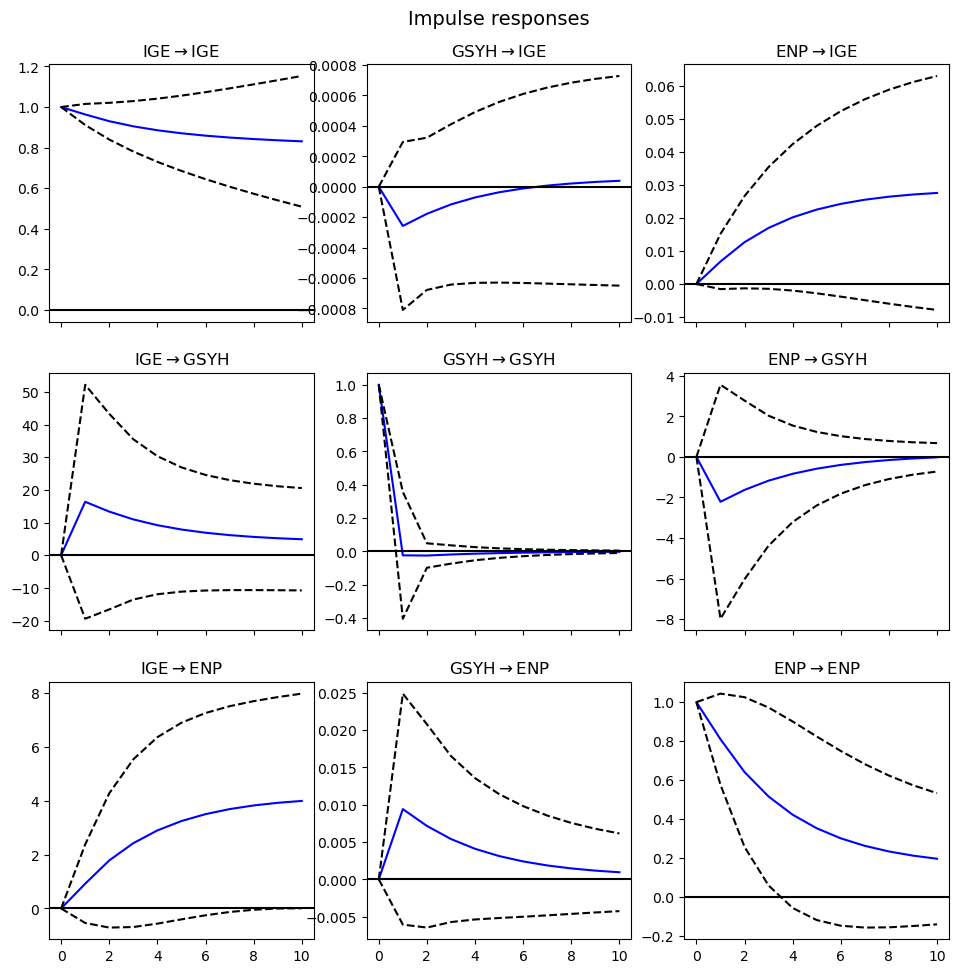

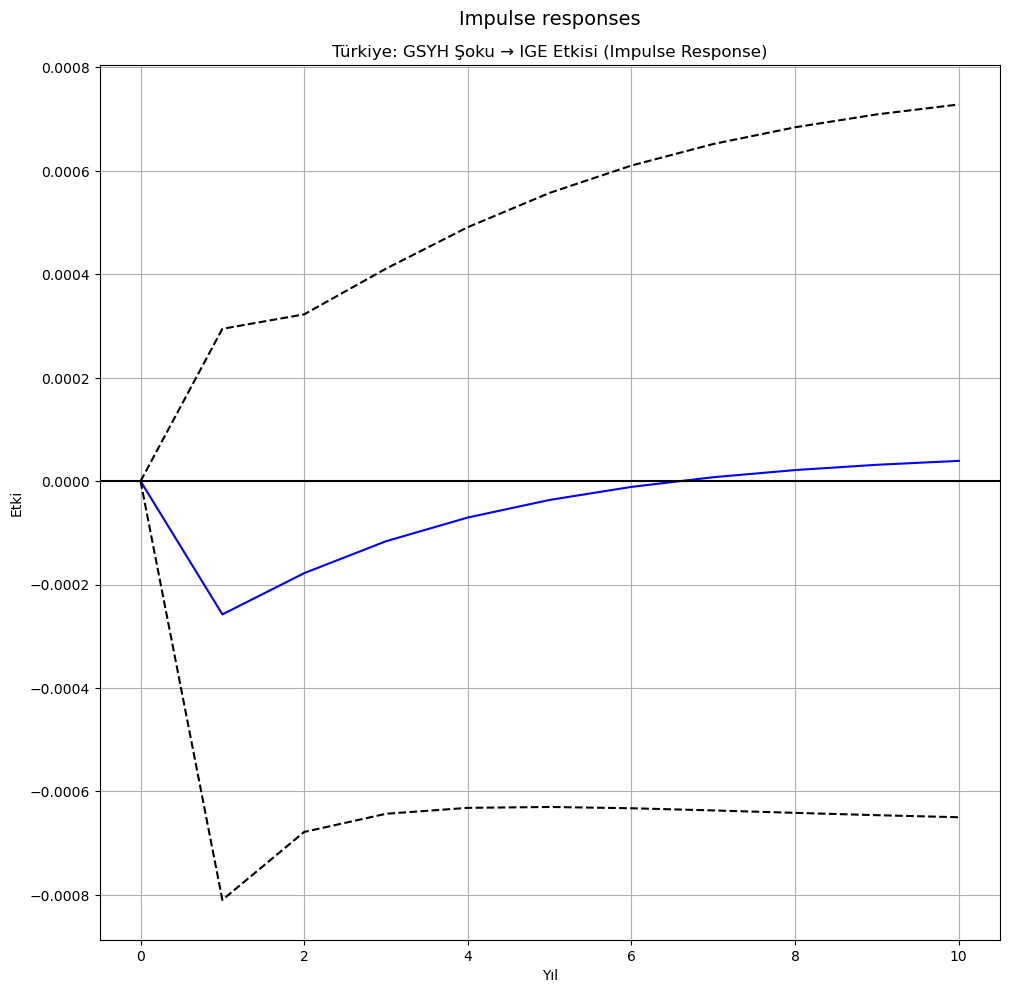

In [159]:
# Impulse Response
irf = var_result.irf(10)

irf.plot(orth=False)
plt.show()

irf.plot(impulse='GSYH', response='IGE')
plt.title('Türkiye: GSYH Şoku → IGE Etkisi (Impulse Response)')
plt.xlabel('Yıl')
plt.ylabel('Etki')
plt.grid(True)
plt.show()


In [161]:
from statsmodels.tsa.api import VAR
var_df = df[['IGE', 'GSYH', 'ENP']].dropna()
var_model = VAR(var_df)
var_result = var_model.fit(1)

print(var_result.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 08, Jun, 2025
Time:                     07:39:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -10.0878
Nobs:                     31.0000    HQIC:                  -10.4619
Log likelihood:           45.0034    FPE:                2.39739e-05
AIC:                     -10.6429    Det(Omega_mle):     1.66579e-05
--------------------------------------------------------------------
Results for equation IGE
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.031659         0.017159            1.845           0.065
L1.IGE          0.963439         0.026526           36.321           0.000
L1.GSYH        -0.000258         0.000282           -0.914           0.361
L1.ENP     

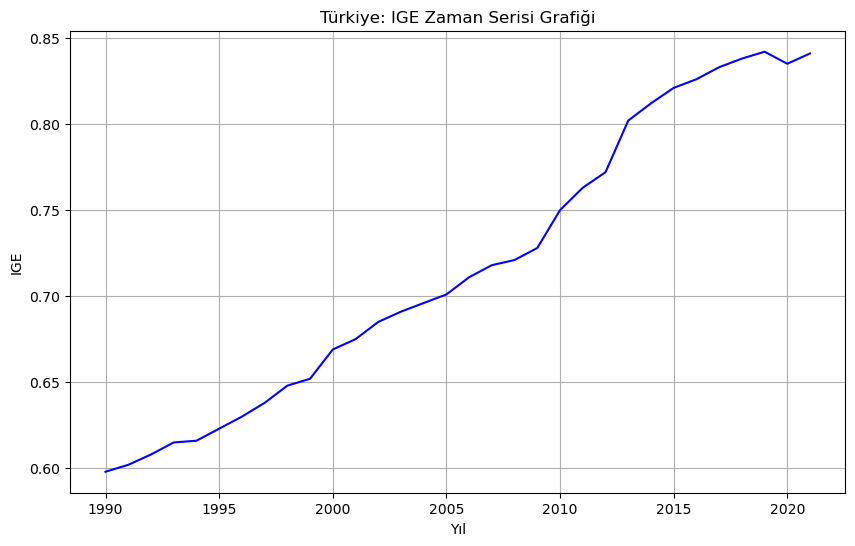

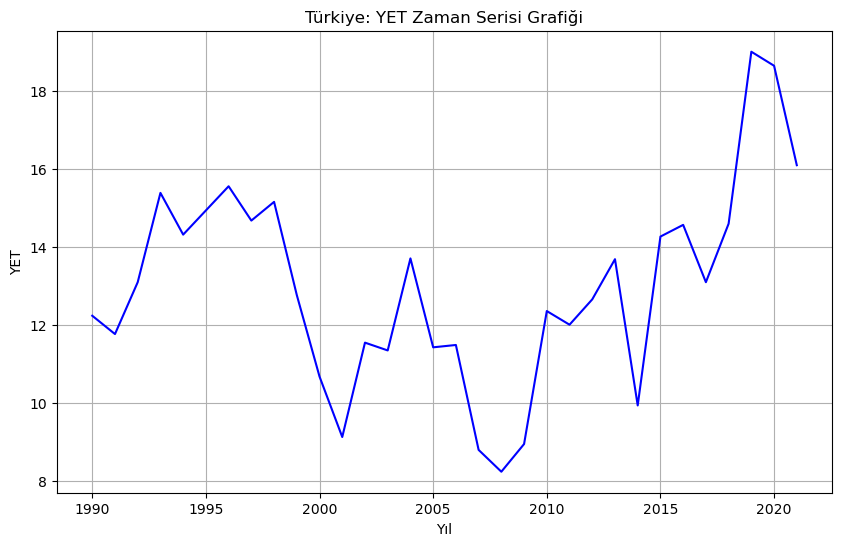

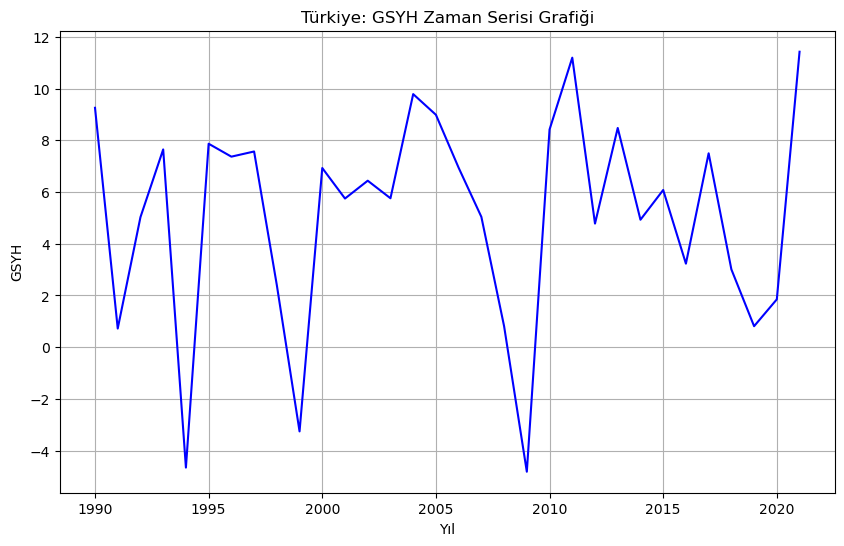

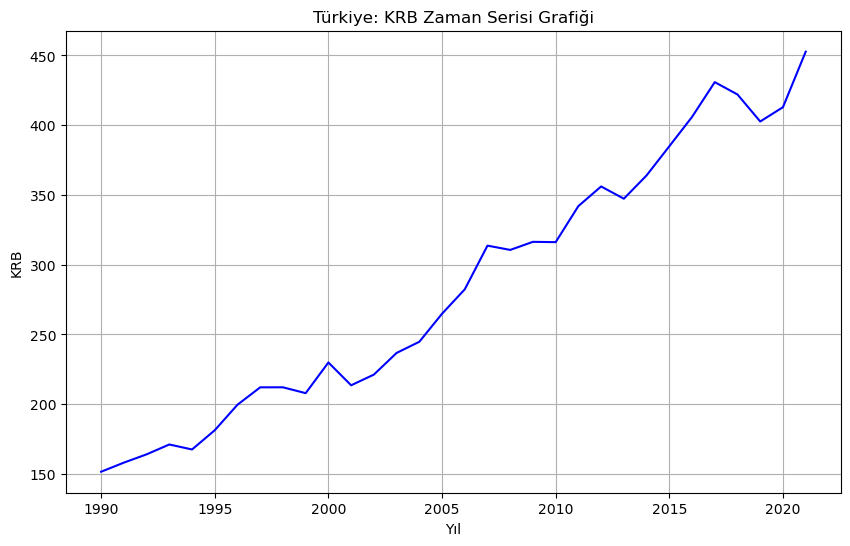

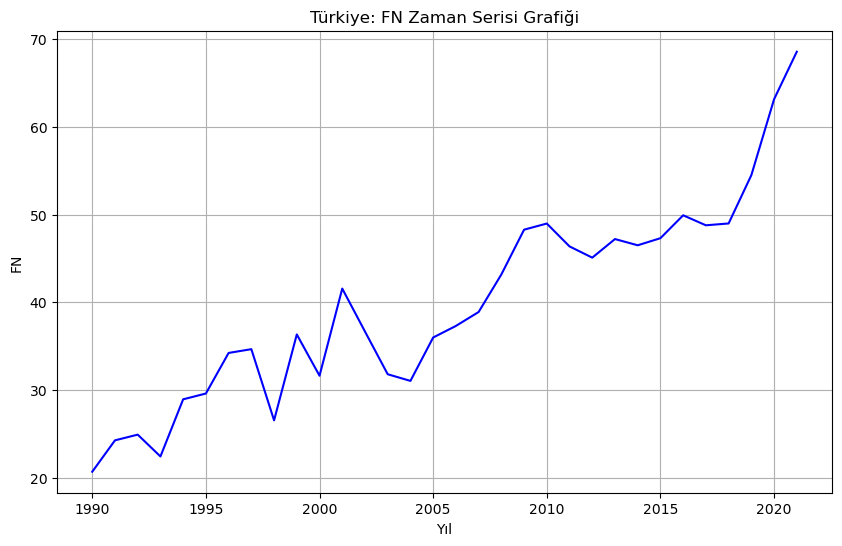

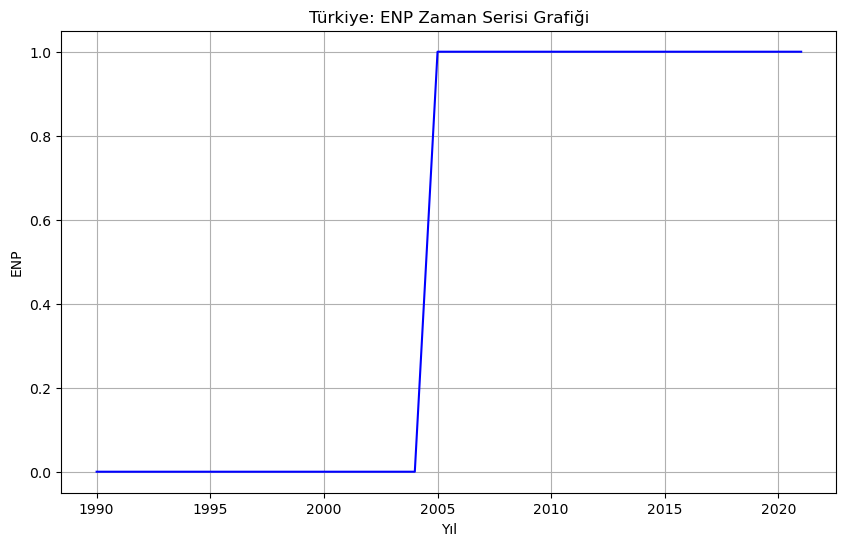

In [163]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('tr_data.xlsx', index_col=0)
variables = df.columns.tolist()

for var in variables:
    plt.figure(figsize=(10,6))
    plt.plot(df.index, df[var], color='blue')
    plt.title(f'Türkiye: {var} Zaman Serisi Grafiği')
    plt.xlabel('Yıl')
    plt.ylabel(var)
    plt.grid(True)
    plt.show()


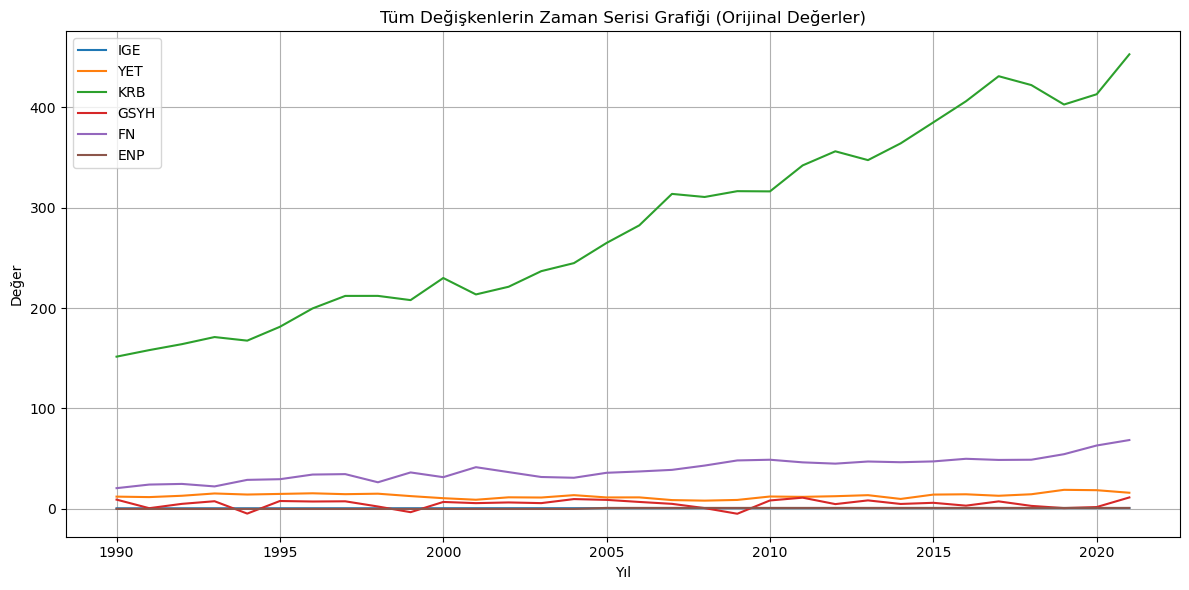

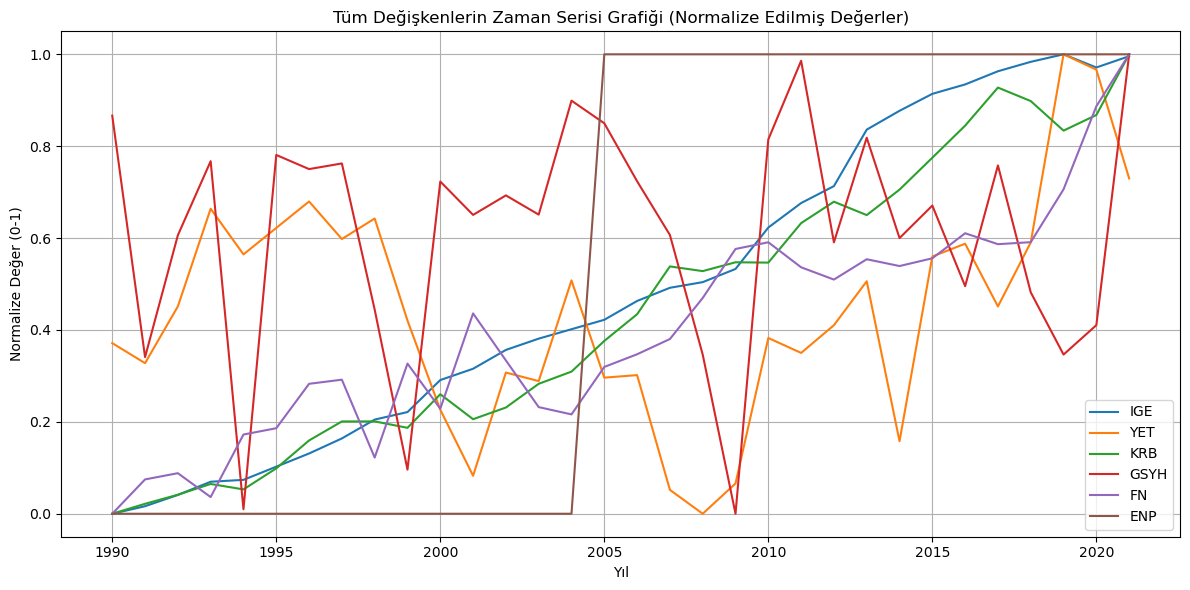

In [165]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_excel("tr_data.xlsx", index_col=0)
df.index = pd.to_datetime(df.index, format='%Y')  # Yıl formatı

plt.figure(figsize=(12, 6))
for var in ['IGE', 'YET', 'KRB', 'GSYH', 'FN', 'ENP']:
    plt.plot(df.index.year, df[var], label=var)

plt.title('Tüm Değişkenlerin Zaman Serisi Grafiği (Orijinal Değerler)')
plt.xlabel('Yıl')
plt.ylabel('Değer')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df[['IGE', 'YET', 'KRB', 'GSYH', 'FN', 'ENP']]),
    index=df.index,
    columns=['IGE', 'YET', 'KRB', 'GSYH', 'FN', 'ENP']
)

plt.figure(figsize=(12, 6))
for var in ['IGE', 'YET', 'KRB', 'GSYH', 'FN', 'ENP']:
    plt.plot(df_normalized.index.year, df_normalized[var], label=var)

plt.title('Tüm Değişkenlerin Zaman Serisi Grafiği (Normalize Edilmiş Değerler)')
plt.xlabel('Yıl')
plt.ylabel('Normalize Değer (0-1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


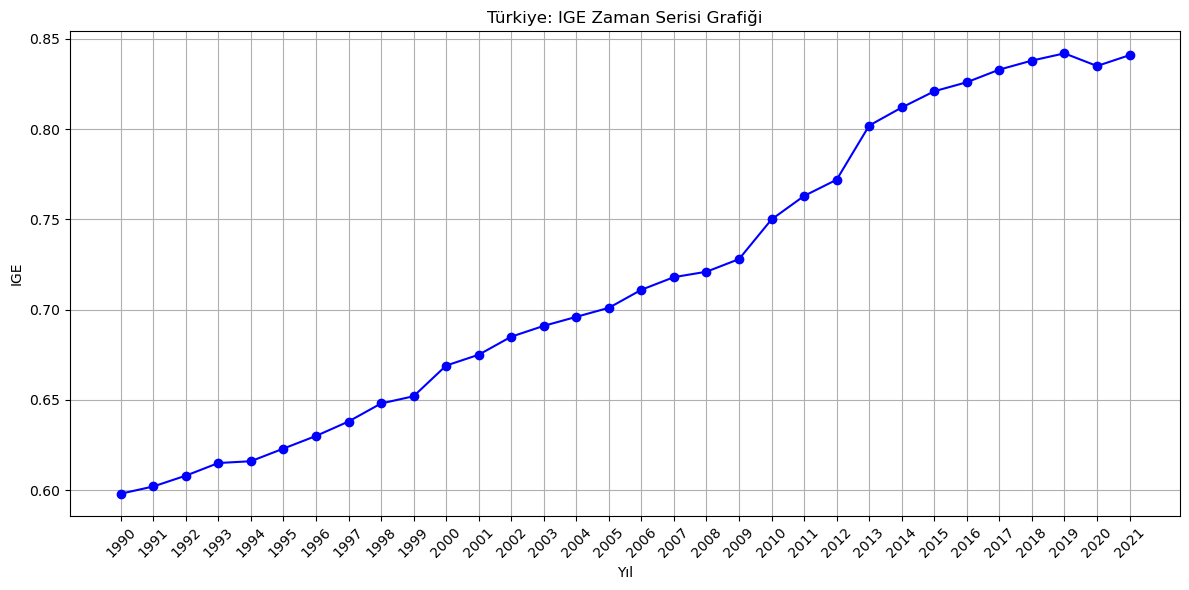

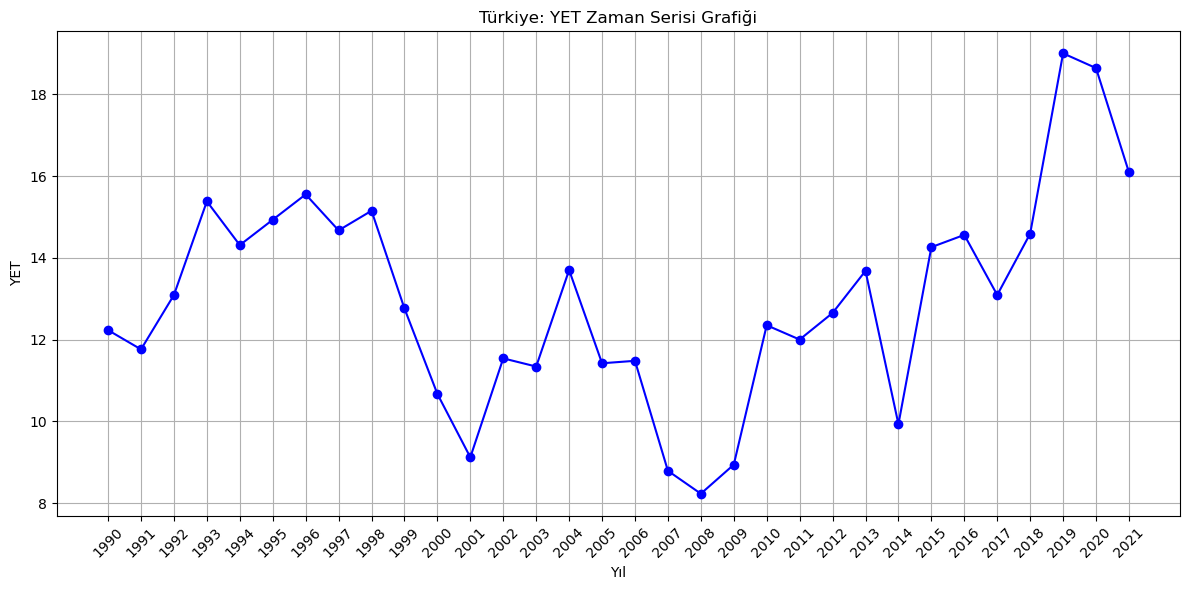

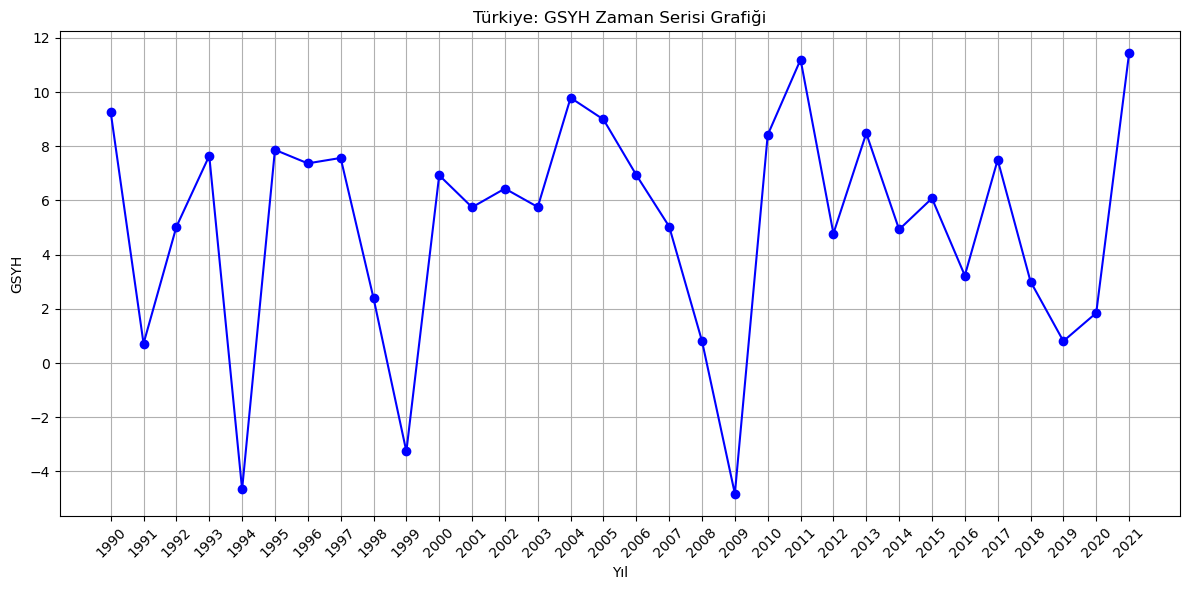

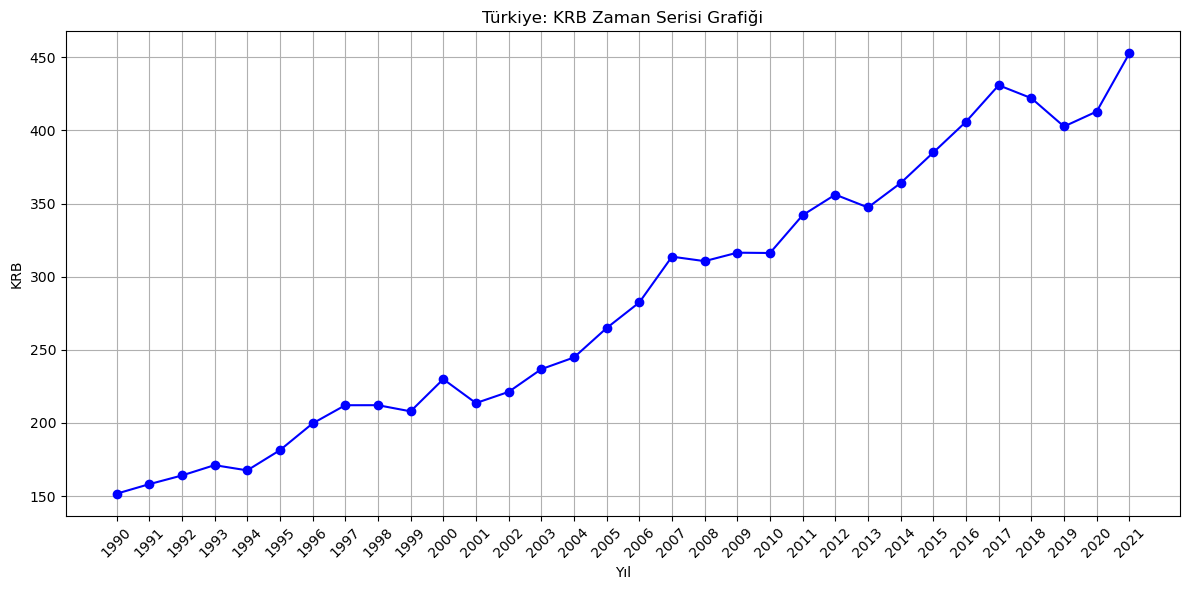

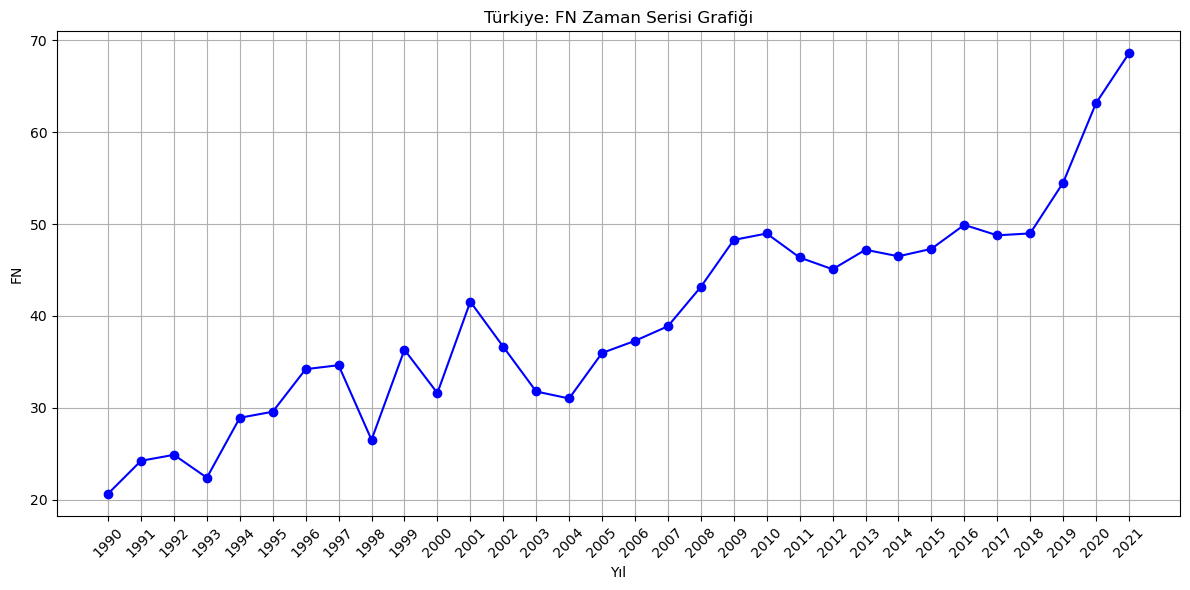

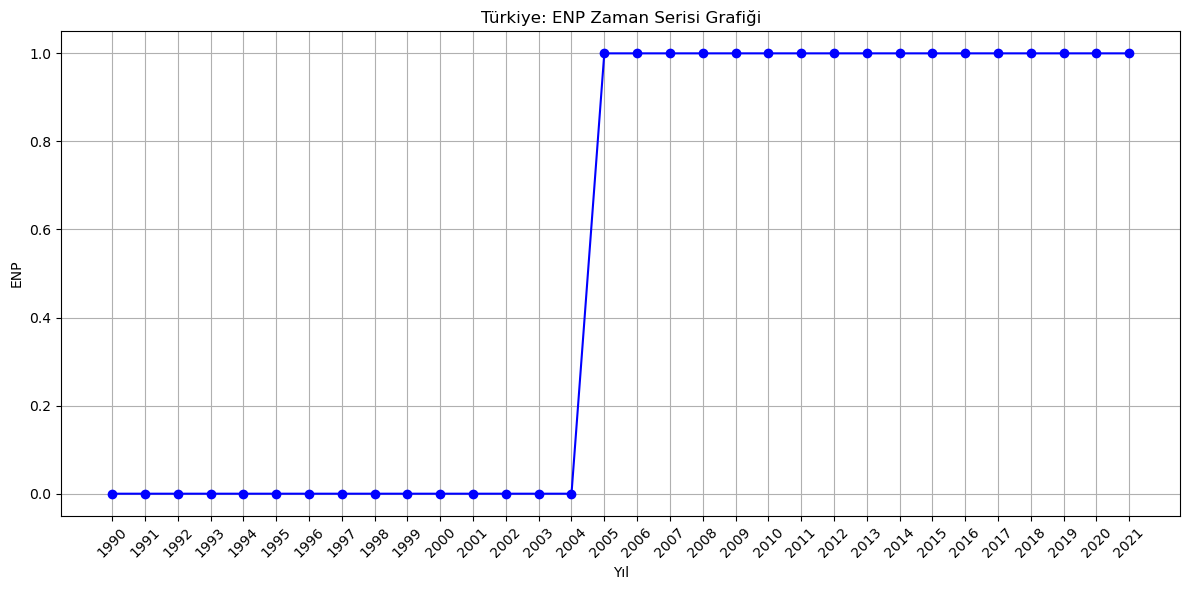

In [167]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('tr_data.xlsx', index_col=0)

variables = df.columns.tolist()

for var in variables:
    plt.figure(figsize=(12,6))
    plt.plot(df.index, df[var], color='blue', marker='o') 
    plt.title(f'Türkiye: {var} Zaman Serisi Grafiği')
    plt.xlabel('Yıl')
    plt.ylabel(var)
    plt.grid(True)
   
    plt.xticks(df.index.tolist(), rotation=45)

    plt.tight_layout()
    plt.show()


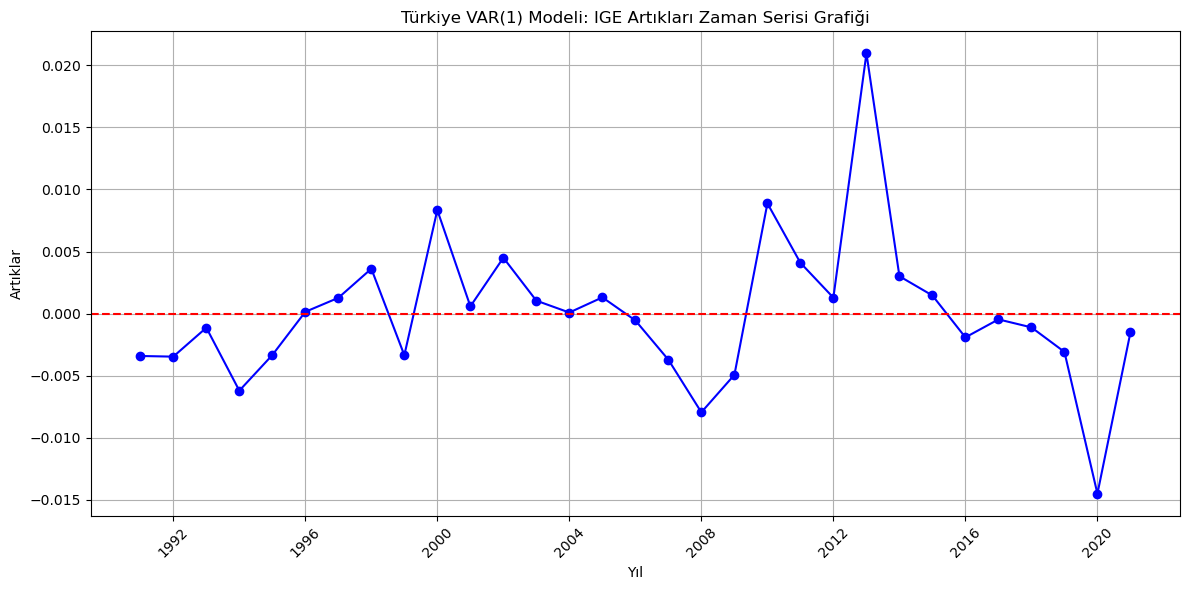

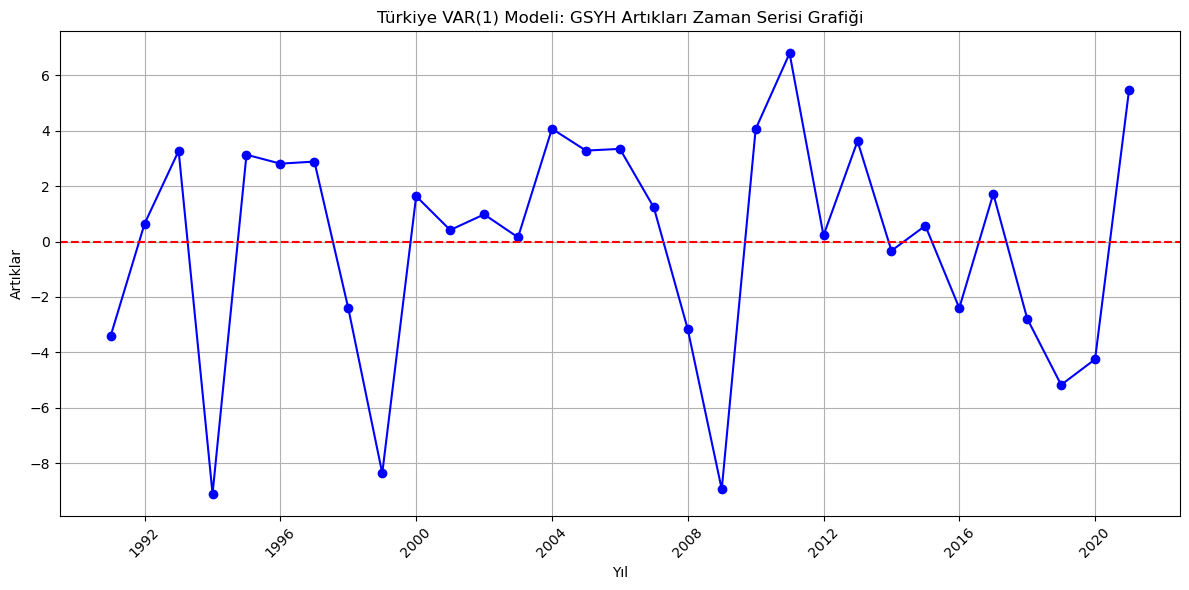

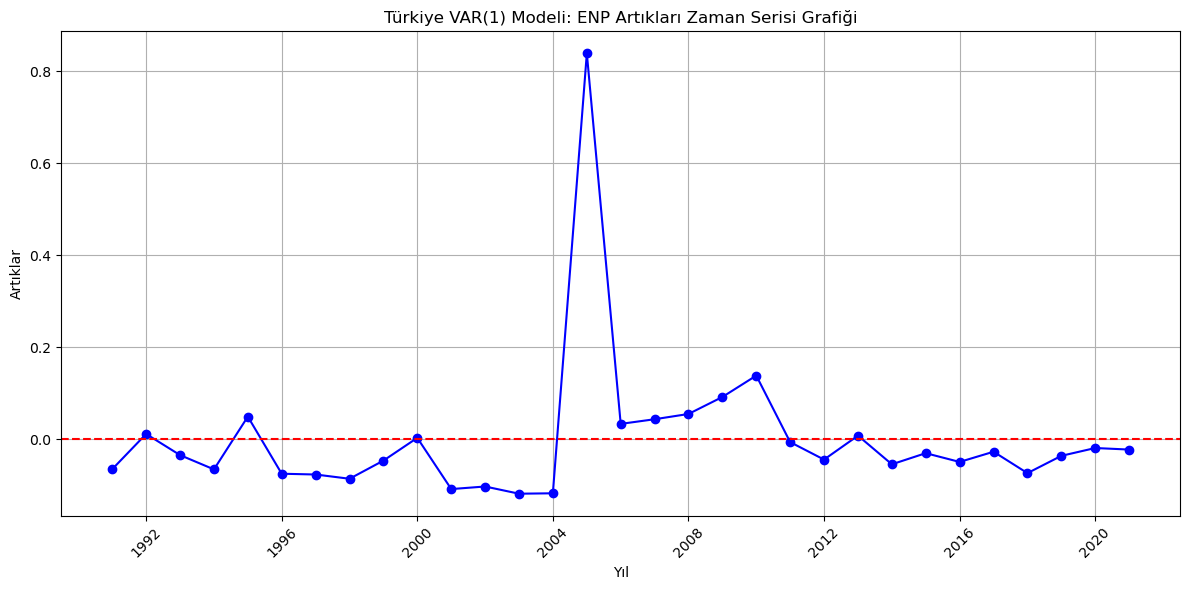

In [169]:
import pandas as pd
import matplotlib.pyplot as plt

residuals = var_result.resid

variables = residuals.columns.tolist()

residuals.index = residuals.index.to_timestamp()

for var in variables:
    plt.figure(figsize=(12,6))
    plt.plot(residuals.index, residuals[var], color='blue', marker='o')
    plt.title(f'Türkiye VAR(1) Modeli: {var} Artıkları Zaman Serisi Grafiği')
    plt.xlabel('Yıl')
    plt.ylabel('Artıklar')
    plt.axhline(0, color='red', linestyle='--')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


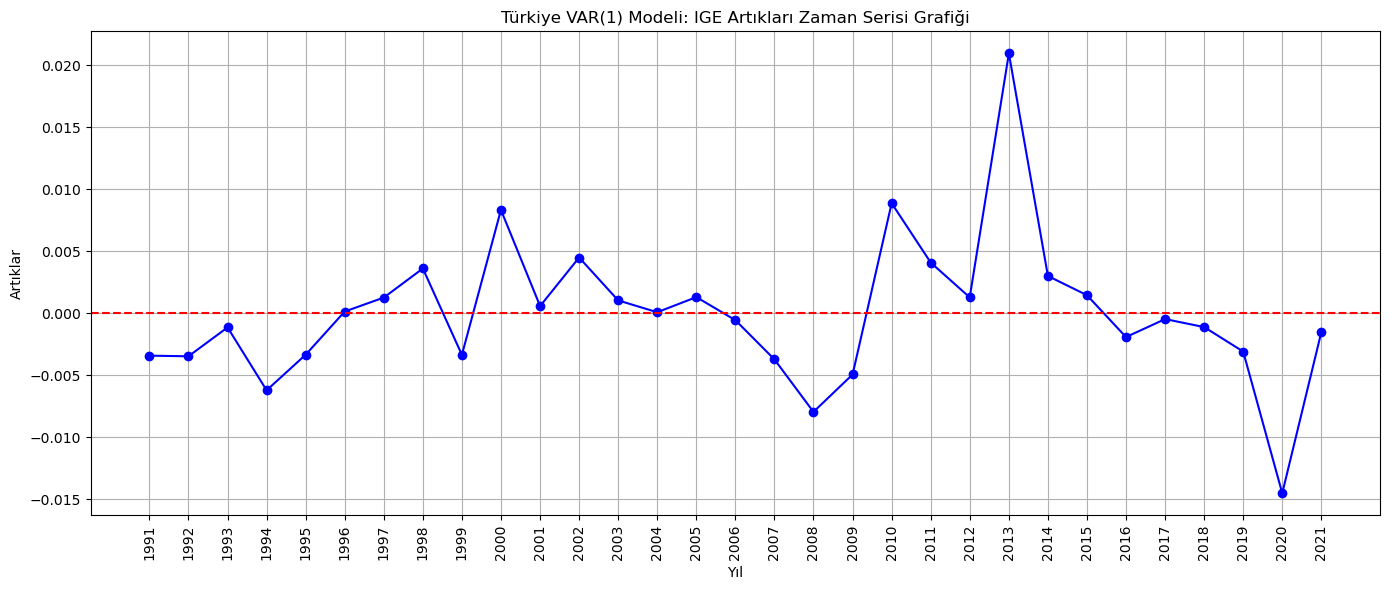

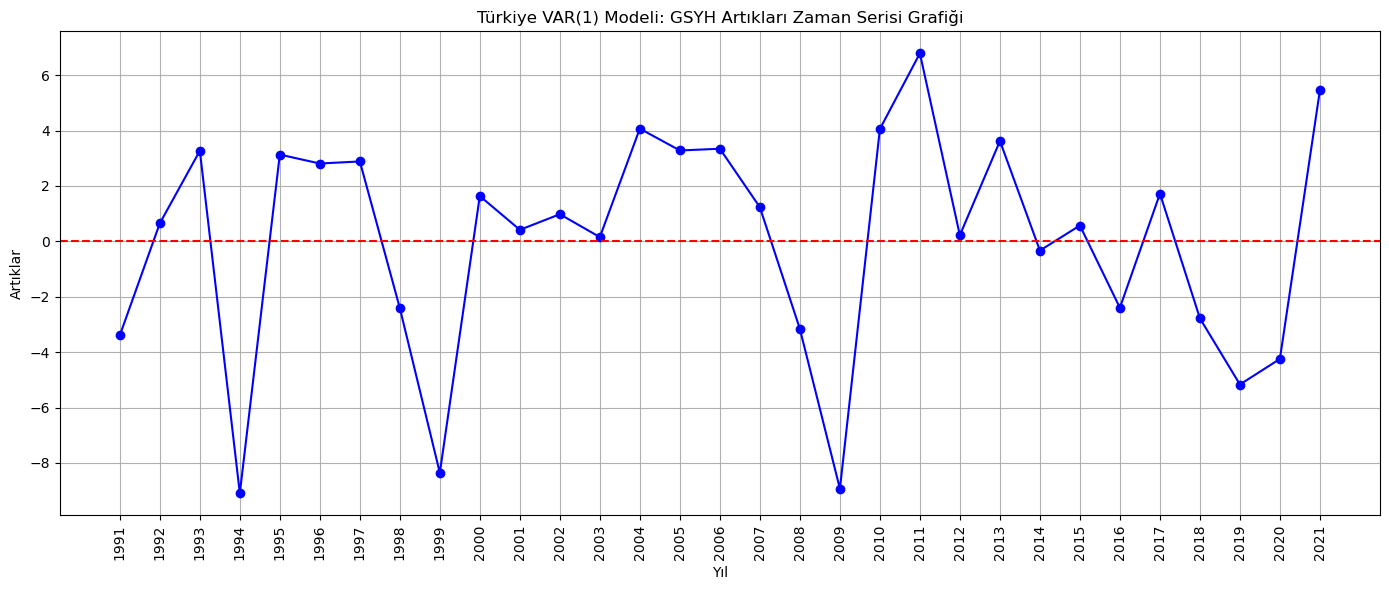

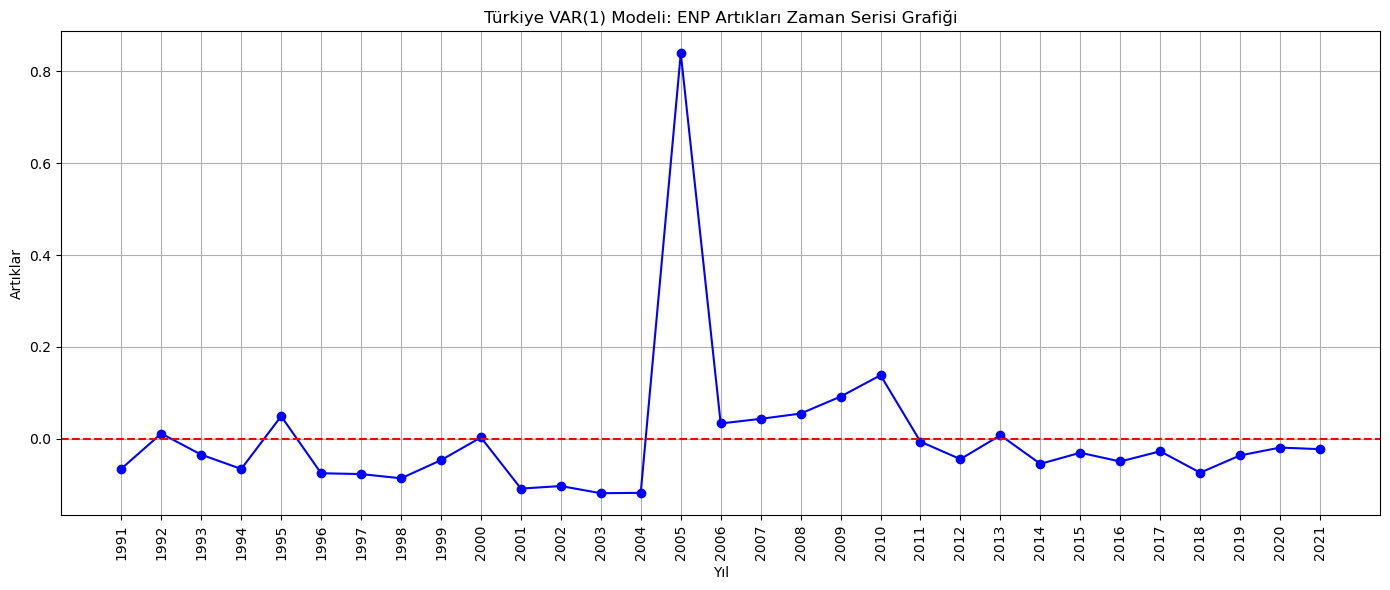

In [197]:
import pandas as pd
import matplotlib.pyplot as plt

residuals = var_result.resid

variables = residuals.columns.tolist()

residuals.index = residuals.index.to_timestamp()

years = residuals.index.year.tolist()

for var in variables:
    plt.figure(figsize=(14,6))
    plt.plot(residuals.index, residuals[var], color='blue', marker='o')
    plt.title(f'Türkiye VAR(1) Modeli: {var} Artıkları Zaman Serisi Grafiği')
    plt.xlabel('Yıl')
    plt.ylabel('Artıklar')
    plt.axhline(0, color='red', linestyle='--') 
    plt.grid(True)
    plt.xticks(ticks=residuals.index, labels=years, rotation=90) 
    plt.tight_layout()
    plt.show()


<Figure size 1000x600 with 0 Axes>

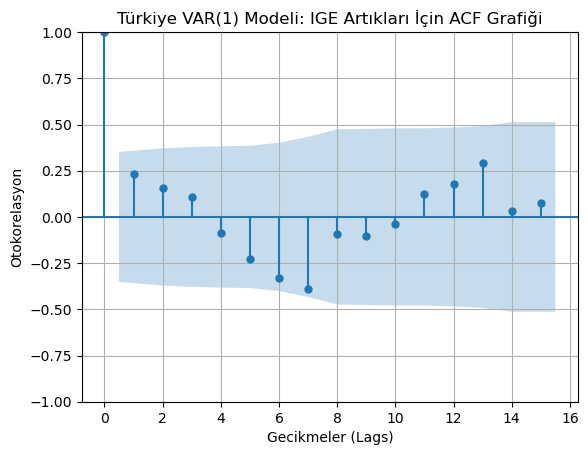

<Figure size 1000x600 with 0 Axes>

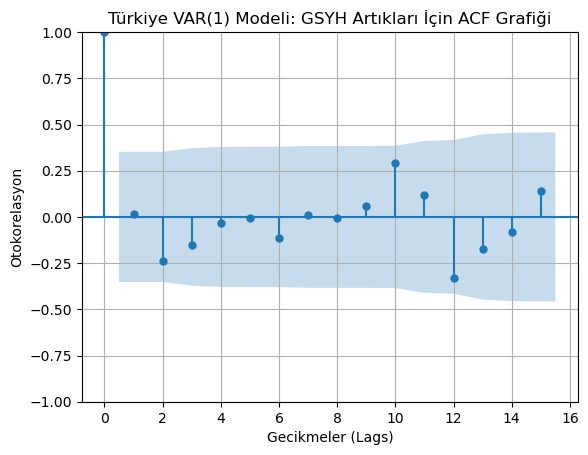

<Figure size 1000x600 with 0 Axes>

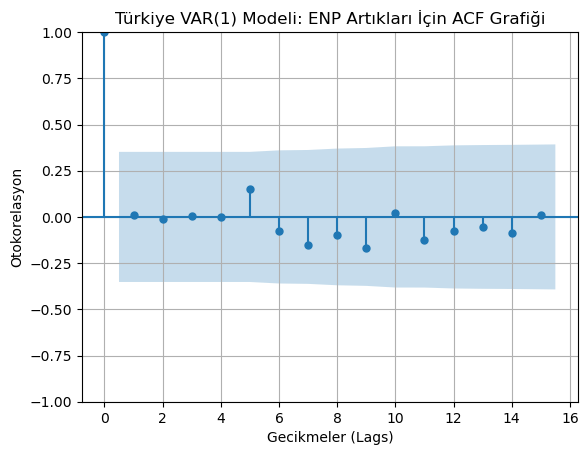

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

residuals = var_result.resid

residuals.index = residuals.index.to_timestamp()

variables = residuals.columns.tolist()

for var in variables:
    plt.figure(figsize=(10,6))
    plot_acf(residuals[var], lags=15)  
    plt.title(f'Türkiye VAR(1) Modeli: {var} Artıkları İçin ACF Grafiği')
    plt.xlabel('Gecikmeler (Lags)')
    plt.ylabel('Otokorelasyon')
    plt.grid(True)
    plt.show()


<Figure size 800x600 with 0 Axes>

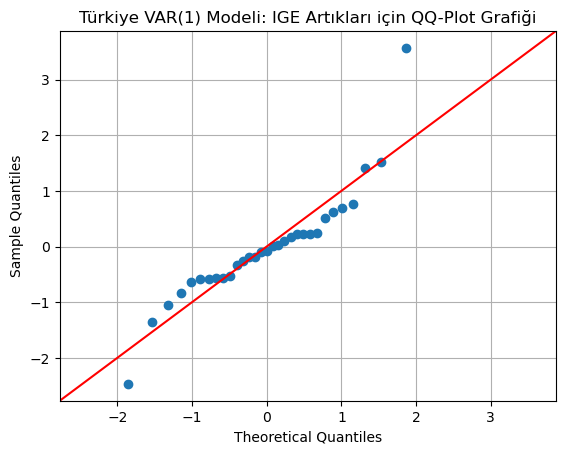

<Figure size 800x600 with 0 Axes>

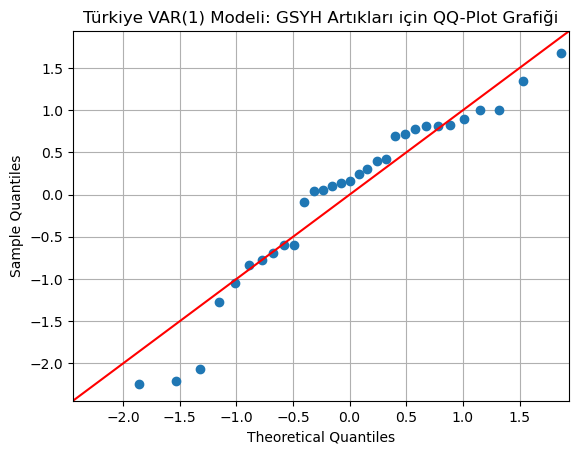

<Figure size 800x600 with 0 Axes>

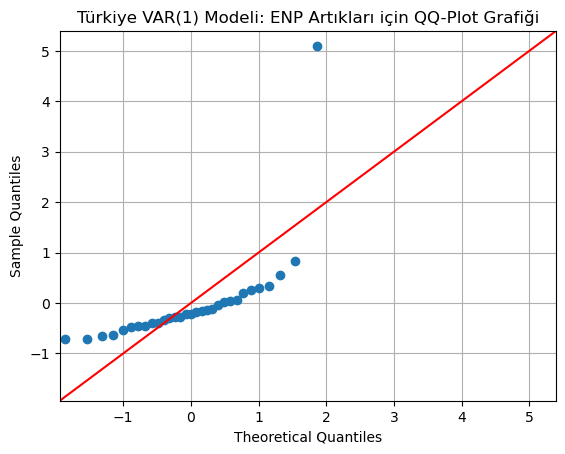

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

residuals = var_result.resid
residuals.index = residuals.index.to_timestamp()

variables = residuals.columns.tolist()

for var in variables:
    plt.figure(figsize=(8,6))
    sm.qqplot(residuals[var], line='45', fit=True)
    plt.title(f'Türkiye VAR(1) Modeli: {var} Artıkları için QQ-Plot Grafiği')
    plt.grid(True)
    plt.show()
